# Non-Parametric Reliability Feature Extraction

This notebook demonstrates non-parametric approaches to extract reliability features for ML:
1. **Savitzky-Golay Filter** - Polynomial smoothing with derivative computation
2. **Moving Average** - Simple rolling window smoothing
3. **Gaussian Smoothing** - Gaussian kernel convolution
4. **LOESS (Local Regression)** - Locally weighted polynomial regression
5. **Kalman Filter** - State-space model with uncertainty tracking
6. **Total Variation Denoising (TVD)** - Preserves sharp transitions while removing noise
7. **Hodrick-Prescott (HP) Filter** - Separates trend from cyclical components
8. **Epanechnikov Kernel** - Optimal kernel smoothing (minimum variance)

**Key Advantage**: No need for parametric model assumptions (no β, λ, etc.). 
The derivative of the smoothed cumulative failure curve directly gives us the failure rate!


In [67]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from scipy.interpolate import interp1d, UnivariateSpline, BSpline, make_interp_spline
from scipy.ndimage import gaussian_filter1d
from scipy import stats
from scipy.optimize import minimize
import warnings
warnings.filterwarnings('ignore')

# For autocorrelation analysis
try:
    from statsmodels.tsa.stattools import acf, pacf
    from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
    STATSMODELS_AVAILABLE = True
except ImportError:
    print("Warning: statsmodels not available. Install with: pip install statsmodels")
    STATSMODELS_AVAILABLE = False

plt.style.use('seaborn-v0_8')
%matplotlib inline


## Why Non-Parametric Methods?

**Advantages over parametric models (Crow-AMSAA, etc.):**
- ✅ No assumptions about failure distribution
- ✅ Automatically adapts to data patterns
- ✅ No need to find optimal change points for piecewise models
- ✅ Simple and computationally efficient
- ✅ Derivative gives direct failure rate estimate
- ✅ Preserves important features while reducing noise
- ✅ Better for ML feature extraction (no model-specific parameters)


In [68]:
class SavitzkyGolayReliability:
    """
    Extract reliability features using Savitzky-Golay filter.
    Uses polynomial fitting in a sliding window to smooth data and compute derivatives.
    """
    
    def __init__(self, window_length=None, polyorder=3):
        """
        Initialize the filter.
        
        Parameters:
        -----------
        window_length : int, optional
            Length of filter window (must be odd). If None, auto-selects based on data size
        polyorder : int
            Order of polynomial used to fit samples (default: 3)
        """
        self.window_length = window_length
        self.polyorder = polyorder
        self.fitted = False
        self.time_points = None
        self.cumulative_smooth = None
        self.failure_rate = None
    
    def fit(self, failure_times, censoring_time=None, time_resolution=None):
        """Fit Savitzky-Golay filter to failure data."""
        failure_times = np.sort(failure_times)
        n = len(failure_times)
        
        if n < 3:
            raise ValueError("Need at least 3 failures to apply Savitzky-Golay filter")
        
        if censoring_time is None:
            censoring_time = failure_times[-1]
        
        # Create cumulative failure data
        actual_cumulative = np.arange(1, n + 1)
        
        # Interpolate to regular time grid for better smoothing
        if time_resolution is None:
            time_resolution = max(50, n * 10)
        
        self.time_points = np.linspace(0, censoring_time, time_resolution)
        
        # Interpolate cumulative failures to regular grid
        interp_func = interp1d(
            failure_times, actual_cumulative, 
            kind='linear', bounds_error=False, fill_value=(0, n)
        )
        cumulative_interp = interp_func(self.time_points)
        cumulative_interp = np.maximum.accumulate(cumulative_interp)  # Ensure monotonic
        
        # Auto-select window length if not provided
        if self.window_length is None:
            suggested = int(time_resolution * 0.15)
            if suggested % 2 == 0:
                suggested += 1
            self.window_length = max(5, min(suggested, time_resolution - 1))
            if self.window_length % 2 == 0:
                self.window_length += 1
        
        # Ensure window_length is valid
        if self.window_length >= len(cumulative_interp):
            self.window_length = len(cumulative_interp) - 1
            if self.window_length % 2 == 0:
                self.window_length -= 1
        
        if self.window_length < self.polyorder + 1:
            self.window_length = self.polyorder + 1
            if self.window_length % 2 == 0:
                self.window_length += 1
        
        # Apply Savitzky-Golay filter to smooth cumulative failures
        self.cumulative_smooth = savgol_filter(
            cumulative_interp, window_length=self.window_length,
            polyorder=self.polyorder, mode='interp'
        )
        self.cumulative_smooth = np.maximum.accumulate(self.cumulative_smooth)
        
        # Compute derivative to get failure rate
        dt = self.time_points[1] - self.time_points[0]
        self.failure_rate = savgol_filter(
            cumulative_interp, window_length=self.window_length,
            polyorder=self.polyorder, deriv=1, delta=dt, mode='interp'
        )
        self.failure_rate = np.maximum(self.failure_rate, 0)
        
        self.fitted = True
        return self
    
    def predict_cumulative(self, time):
        """Predict cumulative failures at time t."""
        if not self.fitted:
            raise ValueError("Model must be fitted first")
        interp_func = interp1d(
            self.time_points, self.cumulative_smooth,
            kind='linear', bounds_error=False,
            fill_value=(0, self.cumulative_smooth[-1])
        )
        return interp_func(time)
    
    def predict_failure_rate(self, time):
        """Predict failure rate at time t."""
        if not self.fitted:
            raise ValueError("Model must be fitted first")
        interp_func = interp1d(
            self.time_points, self.failure_rate,
            kind='linear', bounds_error=False,
            fill_value=(self.failure_rate[0], self.failure_rate[-1])
        )
        return interp_func(time)
    
    def extract_features(self):
        """Extract features from smoothed curve and failure rate for ML."""
        if not self.fitted:
            raise ValueError("Model must be fitted first")
        
        features = {}
        features['total_failures'] = self.cumulative_smooth[-1]
        features['avg_failure_rate'] = np.mean(self.failure_rate)
        features['std_failure_rate'] = np.std(self.failure_rate)
        
        # Trend indicators
        if len(self.failure_rate) > 1:
            slope, intercept, r_value, p_value, _ = stats.linregress(
                self.time_points, self.failure_rate
            )
            features['failure_rate_slope'] = slope
            features['failure_rate_trend_r2'] = r_value ** 2
        
        # Percentiles
        features['failure_rate_p25'] = np.percentile(self.failure_rate, 25)
        features['failure_rate_p50'] = np.percentile(self.failure_rate, 50)
        features['failure_rate_p75'] = np.percentile(self.failure_rate, 75)
        features['failure_rate_p90'] = np.percentile(self.failure_rate, 90)
        
        # Rate of change in failure rate (second derivative)
        if len(self.failure_rate) > 1:
            dt = self.time_points[1] - self.time_points[0]
            second_deriv = np.gradient(self.failure_rate, dt)
            features['failure_rate_acceleration'] = np.mean(second_deriv)
        
        # Time-based features
        total_time = self.time_points[-1]
        features['total_time'] = total_time
        features['failures_per_unit_time'] = features['total_failures'] / total_time if total_time > 0 else 0
        
        # Early vs late period comparison
        mid_point = len(self.time_points) // 2
        early_rate = np.mean(self.failure_rate[:mid_point])
        late_rate = np.mean(self.failure_rate[mid_point:])
        features['early_period_rate'] = early_rate
        features['late_period_rate'] = late_rate
        features['rate_change_ratio'] = late_rate / early_rate if early_rate > 0 else 0
        
        # Variability
        features['failure_rate_cv'] = features['std_failure_rate'] / features['avg_failure_rate'] if features['avg_failure_rate'] > 0 else 0
        features['peak_failure_rate'] = np.max(self.failure_rate)
        
        return features
    
    def extract_timeseries_features(self, n_lags=5, window_sizes=[7, 14, 30]):
        """
        Extract time series features for ML models.
        
        Parameters:
        -----------
        n_lags : int
            Number of lag features to create (default: 5)
        window_sizes : list
            Window sizes for rolling statistics (default: [7, 14, 30])
        
        Returns:
        --------
        features : dict
            Time series features including raw data and derived features
        """
        if not self.fitted:
            raise ValueError("Model must be fitted first")
        
        features = {}
        
        # 1. Raw time series data (for direct use in LSTM/RNN/Transformer models)
        features['timeseries_data'] = {
            'time_points': self.time_points.copy(),
            'failure_rate': self.failure_rate.copy(),
            'cumulative_failures': self.cumulative_smooth.copy()
        }
        
        # 2. Lag features (previous values)
        for lag in range(1, n_lags + 1):
            if len(self.failure_rate) > lag:
                lag_values = np.roll(self.failure_rate, lag)
                lag_values[:lag] = np.nan
                features[f'failure_rate_lag_{lag}'] = lag_values
        
        # 3. Rolling window statistics
        for window in window_sizes:
            if len(self.failure_rate) >= window:
                rolling_mean = pd.Series(self.failure_rate).rolling(window=window, min_periods=1).mean()
                rolling_std = pd.Series(self.failure_rate).rolling(window=window, min_periods=1).std()
                rolling_min = pd.Series(self.failure_rate).rolling(window=window, min_periods=1).min()
                rolling_max = pd.Series(self.failure_rate).rolling(window=window, min_periods=1).max()
                
                features[f'rolling_mean_{window}'] = rolling_mean.values
                features[f'rolling_std_{window}'] = rolling_std.values
                features[f'rolling_min_{window}'] = rolling_min.values
                features[f'rolling_max_{window}'] = rolling_max.values
        
        # 4. Autocorrelation features (temporal dependencies)
        autocorr_features = {}
        for lag in [1, 7, 14, 30]:
            if len(self.failure_rate) > lag:
                try:
                    acf = np.corrcoef(self.failure_rate[:-lag], self.failure_rate[lag:])[0, 1]
                    autocorr_features[f'autocorr_lag_{lag}'] = acf if not np.isnan(acf) else 0
                except:
                    autocorr_features[f'autocorr_lag_{lag}'] = 0
        features['autocorrelation'] = autocorr_features
        
        # 5. Volatility features (GARCH-like measures)
        if len(self.failure_rate) > 1:
            # Calculate returns (percentage change)
            returns = np.diff(self.failure_rate) / (self.failure_rate[:-1] + 1e-10)
            features['volatility'] = np.std(returns)
            features['mean_absolute_change'] = np.mean(np.abs(returns))
            
            # Volatility clustering (correlation of squared returns)
            if len(returns) > 1:
                try:
                    vol_cluster = np.corrcoef(returns[:-1]**2, returns[1:]**2)[0, 1]
                    features['volatility_clustering'] = vol_cluster if not np.isnan(vol_cluster) else 0
                except:
                    features['volatility_clustering'] = 0
            else:
                features['volatility_clustering'] = 0
        
        # 6. Trend decomposition
        if len(self.failure_rate) > 1:
            # Detrend using moving average
            trend_window = min(30, len(self.failure_rate) // 4)
            trend = pd.Series(self.failure_rate).rolling(
                window=trend_window, center=True, min_periods=1
            ).mean()
            detrended = self.failure_rate - trend.values
            
            features['trend_component'] = trend.values
            features['detrended_component'] = detrended
            features['trend_strength'] = np.var(trend.values) / (np.var(self.failure_rate) + 1e-10)
            features['detrended_std'] = np.std(detrended)
        
        # 7. Change point detection (simple variance-based)
        if len(self.failure_rate) > 10:
            # Split into segments and compare variance
            n_segments = 3
            segment_size = len(self.failure_rate) // n_segments
            segment_vars = []
            for i in range(n_segments):
                start = i * segment_size
                end = (i + 1) * segment_size if i < n_segments - 1 else len(self.failure_rate)
                segment_vars.append(np.var(self.failure_rate[start:end]))
            features['variance_change'] = np.std(segment_vars) / (np.mean(segment_vars) + 1e-10)
        else:
            features['variance_change'] = 0
        
        # 8. Time-based features
        features['time_since_start'] = self.time_points - self.time_points[0]
        features['time_normalized'] = self.time_points / (self.time_points[-1] + 1e-10)
        
        # 9. Summary statistics for time series
        features['timeseries_summary'] = {
            'mean': np.mean(self.failure_rate),
            'std': np.std(self.failure_rate),
            'min': np.min(self.failure_rate),
            'max': np.max(self.failure_rate),
            'range': np.max(self.failure_rate) - np.min(self.failure_rate),
            'cv': np.std(self.failure_rate) / (np.mean(self.failure_rate) + 1e-10),
            'skewness': stats.skew(self.failure_rate),
            'kurtosis': stats.kurtosis(self.failure_rate)
        }
        
        return features


In [69]:
class MovingAverageReliability:
    """
    Extract reliability features using moving average smoothing.
    Simple but effective for noisy data.
    """
    
    def __init__(self, window_size=None):
        """
        Initialize the smoother.
        
        Parameters:
        -----------
        window_size : int, optional
            Size of moving average window. If None, auto-selects.
        """
        self.window_size = window_size
        self.fitted = False
        self.time_points = None
        self.cumulative_smooth = None
        self.failure_rate = None
    
    def fit(self, failure_times, censoring_time=None, time_resolution=None):
        """Fit moving average to failure data."""
        failure_times = np.sort(failure_times)
        n = len(failure_times)
        
        if n < 3:
            raise ValueError("Need at least 3 failures")
        
        if censoring_time is None:
            censoring_time = failure_times[-1]
        
        actual_cumulative = np.arange(1, n + 1)
        
        if time_resolution is None:
            time_resolution = max(50, n * 10)
        
        self.time_points = np.linspace(0, censoring_time, time_resolution)
        
        # Interpolate to regular grid
        interp_func = interp1d(
            failure_times, actual_cumulative,
            kind='linear', bounds_error=False, fill_value=(0, n)
        )
        cumulative_interp = interp_func(self.time_points)
        cumulative_interp = np.maximum.accumulate(cumulative_interp)
        
        # Auto-select window size
        if self.window_size is None:
            self.window_size = max(3, int(time_resolution * 0.1))
        
        # Apply moving average
        self.cumulative_smooth = pd.Series(cumulative_interp).rolling(
            window=self.window_size, center=True, min_periods=1
        ).mean().values
        
        # Compute derivative using numerical differentiation
        dt = self.time_points[1] - self.time_points[0]
        self.failure_rate = np.gradient(self.cumulative_smooth, dt)
        self.failure_rate = np.maximum(self.failure_rate, 0)
        
        self.fitted = True
        return self
    
    def predict_cumulative(self, time):
        """Predict cumulative failures at time t."""
        if not self.fitted:
            raise ValueError("Model must be fitted first")
        interp_func = interp1d(
            self.time_points, self.cumulative_smooth,
            kind='linear', bounds_error=False,
            fill_value=(0, self.cumulative_smooth[-1])
        )
        return interp_func(time)
    
    def predict_failure_rate(self, time):
        """Predict failure rate at time t."""
        if not self.fitted:
            raise ValueError("Model must be fitted first")
        interp_func = interp1d(
            self.time_points, self.failure_rate,
            kind='linear', bounds_error=False,
            fill_value=(self.failure_rate[0], self.failure_rate[-1])
        )
        return interp_func(time)
    
    def extract_features(self):
        """Extract features for ML."""
        if not self.fitted:
            raise ValueError("Model must be fitted first")
        
        features = {}
        features['total_failures'] = self.cumulative_smooth[-1]
        features['avg_failure_rate'] = np.mean(self.failure_rate)
        features['std_failure_rate'] = np.std(self.failure_rate)
        
        # Trend indicators
        if len(self.failure_rate) > 1:
            slope, intercept, r_value, p_value, _ = stats.linregress(
                self.time_points, self.failure_rate
            )
            features['failure_rate_slope'] = slope
            features['failure_rate_trend_r2'] = r_value ** 2
        
        # Percentiles
        features['failure_rate_p25'] = np.percentile(self.failure_rate, 25)
        features['failure_rate_p50'] = np.percentile(self.failure_rate, 50)
        features['failure_rate_p75'] = np.percentile(self.failure_rate, 75)
        features['failure_rate_p90'] = np.percentile(self.failure_rate, 90)
        
        # Rate of change in failure rate (second derivative)
        if len(self.failure_rate) > 1:
            dt = self.time_points[1] - self.time_points[0]
            second_deriv = np.gradient(self.failure_rate, dt)
            features['failure_rate_acceleration'] = np.mean(second_deriv)
        
        # Time-based features
        total_time = self.time_points[-1]
        features['total_time'] = total_time
        features['failures_per_unit_time'] = features['total_failures'] / total_time if total_time > 0 else 0
        
        # Early vs late period comparison
        mid_point = len(self.time_points) // 2
        early_rate = np.mean(self.failure_rate[:mid_point])
        late_rate = np.mean(self.failure_rate[mid_point:])
        features['early_period_rate'] = early_rate
        features['late_period_rate'] = late_rate
        features['rate_change_ratio'] = late_rate / early_rate if early_rate > 0 else 0
        
        # Variability
        features['failure_rate_cv'] = features['std_failure_rate'] / features['avg_failure_rate'] if features['avg_failure_rate'] > 0 else 0
        features['peak_failure_rate'] = np.max(self.failure_rate)
        
        return features
    
    def extract_timeseries_features(self, n_lags=5, window_sizes=[7, 14, 30]):
        """Extract time series features for ML models."""
        if not self.fitted:
            raise ValueError("Model must be fitted first")
        
        features = {}
        features['timeseries_data'] = {
            'time_points': self.time_points.copy(),
            'failure_rate': self.failure_rate.copy(),
            'cumulative_failures': self.cumulative_smooth.copy()
        }
        
        for lag in range(1, n_lags + 1):
            if len(self.failure_rate) > lag:
                lag_values = np.roll(self.failure_rate, lag)
                lag_values[:lag] = np.nan
                features[f'failure_rate_lag_{lag}'] = lag_values
        
        for window in window_sizes:
            if len(self.failure_rate) >= window:
                rolling_mean = pd.Series(self.failure_rate).rolling(window=window, min_periods=1).mean()
                rolling_std = pd.Series(self.failure_rate).rolling(window=window, min_periods=1).std()
                rolling_min = pd.Series(self.failure_rate).rolling(window=window, min_periods=1).min()
                rolling_max = pd.Series(self.failure_rate).rolling(window=window, min_periods=1).max()
                features[f'rolling_mean_{window}'] = rolling_mean.values
                features[f'rolling_std_{window}'] = rolling_std.values
                features[f'rolling_min_{window}'] = rolling_min.values
                features[f'rolling_max_{window}'] = rolling_max.values
        
        autocorr_features = {}
        for lag in [1, 7, 14, 30]:
            if len(self.failure_rate) > lag:
                try:
                    acf = np.corrcoef(self.failure_rate[:-lag], self.failure_rate[lag:])[0, 1]
                    autocorr_features[f'autocorr_lag_{lag}'] = acf if not np.isnan(acf) else 0
                except:
                    autocorr_features[f'autocorr_lag_{lag}'] = 0
        features['autocorrelation'] = autocorr_features
        
        if len(self.failure_rate) > 1:
            returns = np.diff(self.failure_rate) / (self.failure_rate[:-1] + 1e-10)
            features['volatility'] = np.std(returns)
            features['mean_absolute_change'] = np.mean(np.abs(returns))
            if len(returns) > 1:
                try:
                    vol_cluster = np.corrcoef(returns[:-1]**2, returns[1:]**2)[0, 1]
                    features['volatility_clustering'] = vol_cluster if not np.isnan(vol_cluster) else 0
                except:
                    features['volatility_clustering'] = 0
            else:
                features['volatility_clustering'] = 0
        
        if len(self.failure_rate) > 1:
            trend_window = min(30, len(self.failure_rate) // 4)
            trend = pd.Series(self.failure_rate).rolling(window=trend_window, center=True, min_periods=1).mean()
            detrended = self.failure_rate - trend.values
            features['trend_component'] = trend.values
            features['detrended_component'] = detrended
            features['trend_strength'] = np.var(trend.values) / (np.var(self.failure_rate) + 1e-10)
            features['detrended_std'] = np.std(detrended)
        
        if len(self.failure_rate) > 10:
            n_segments = 3
            segment_size = len(self.failure_rate) // n_segments
            segment_vars = []
            for i in range(n_segments):
                start = i * segment_size
                end = (i + 1) * segment_size if i < n_segments - 1 else len(self.failure_rate)
                segment_vars.append(np.var(self.failure_rate[start:end]))
            features['variance_change'] = np.std(segment_vars) / (np.mean(segment_vars) + 1e-10)
        else:
            features['variance_change'] = 0
        
        features['time_since_start'] = self.time_points - self.time_points[0]
        features['time_normalized'] = self.time_points / (self.time_points[-1] + 1e-10)
        
        features['timeseries_summary'] = {
            'mean': np.mean(self.failure_rate),
            'std': np.std(self.failure_rate),
            'min': np.min(self.failure_rate),
            'max': np.max(self.failure_rate),
            'range': np.max(self.failure_rate) - np.min(self.failure_rate),
            'cv': np.std(self.failure_rate) / (np.mean(self.failure_rate) + 1e-10),
            'skewness': stats.skew(self.failure_rate),
            'kurtosis': stats.kurtosis(self.failure_rate)
        }
        
        return features


In [70]:
class GaussianSmoothingReliability:
    """
    Extract reliability features using Gaussian kernel smoothing.
    Good for preserving smooth trends.
    """
    
    def __init__(self, sigma=None):
        """
        Initialize the smoother.
        
        Parameters:
        -----------
        sigma : float, optional
            Standard deviation of Gaussian kernel. If None, auto-selects.
        """
        self.sigma = sigma
        self.fitted = False
        self.time_points = None
        self.cumulative_smooth = None
        self.failure_rate = None
    
    def fit(self, failure_times, censoring_time=None, time_resolution=None):
        """Fit Gaussian smoothing to failure data."""
        failure_times = np.sort(failure_times)
        n = len(failure_times)
        
        if n < 3:
            raise ValueError("Need at least 3 failures")
        
        if censoring_time is None:
            censoring_time = failure_times[-1]
        
        actual_cumulative = np.arange(1, n + 1)
        
        if time_resolution is None:
            time_resolution = max(50, n * 10)
        
        self.time_points = np.linspace(0, censoring_time, time_resolution)
        
        # Interpolate to regular grid
        interp_func = interp1d(
            failure_times, actual_cumulative,
            kind='linear', bounds_error=False, fill_value=(0, n)
        )
        cumulative_interp = interp_func(self.time_points)
        cumulative_interp = np.maximum.accumulate(cumulative_interp)
        
        # Auto-select sigma
        if self.sigma is None:
            dt = self.time_points[1] - self.time_points[0]
            self.sigma = max(1.0, dt * 5)  # 5 time steps
        
        # Apply Gaussian smoothing
        self.cumulative_smooth = gaussian_filter1d(
            cumulative_interp, sigma=self.sigma
        )
        self.cumulative_smooth = np.maximum.accumulate(self.cumulative_smooth)
        
        # Compute derivative
        dt = self.time_points[1] - self.time_points[0]
        self.failure_rate = np.gradient(self.cumulative_smooth, dt)
        self.failure_rate = np.maximum(self.failure_rate, 0)
        
        self.fitted = True
        return self
    
    def predict_cumulative(self, time):
        """Predict cumulative failures at time t."""
        if not self.fitted:
            raise ValueError("Model must be fitted first")
        interp_func = interp1d(
            self.time_points, self.cumulative_smooth,
            kind='linear', bounds_error=False,
            fill_value=(0, self.cumulative_smooth[-1])
        )
        return interp_func(time)
    
    def predict_failure_rate(self, time):
        """Predict failure rate at time t."""
        if not self.fitted:
            raise ValueError("Model must be fitted first")
        interp_func = interp1d(
            self.time_points, self.failure_rate,
            kind='linear', bounds_error=False,
            fill_value=(self.failure_rate[0], self.failure_rate[-1])
        )
        return interp_func(time)
    
    def extract_features(self):
        """Extract features for ML."""
        if not self.fitted:
            raise ValueError("Model must be fitted first")
        
        features = {}
        features['total_failures'] = self.cumulative_smooth[-1]
        features['avg_failure_rate'] = np.mean(self.failure_rate)
        features['std_failure_rate'] = np.std(self.failure_rate)
        
        # Trend indicators
        if len(self.failure_rate) > 1:
            slope, intercept, r_value, p_value, _ = stats.linregress(
                self.time_points, self.failure_rate
            )
            features['failure_rate_slope'] = slope
            features['failure_rate_trend_r2'] = r_value ** 2
        
        # Percentiles
        features['failure_rate_p25'] = np.percentile(self.failure_rate, 25)
        features['failure_rate_p50'] = np.percentile(self.failure_rate, 50)
        features['failure_rate_p75'] = np.percentile(self.failure_rate, 75)
        features['failure_rate_p90'] = np.percentile(self.failure_rate, 90)
        
        # Rate of change in failure rate (second derivative)
        if len(self.failure_rate) > 1:
            dt = self.time_points[1] - self.time_points[0]
            second_deriv = np.gradient(self.failure_rate, dt)
            features['failure_rate_acceleration'] = np.mean(second_deriv)
        
        # Time-based features
        total_time = self.time_points[-1]
        features['total_time'] = total_time
        features['failures_per_unit_time'] = features['total_failures'] / total_time if total_time > 0 else 0
        
        # Early vs late period comparison
        mid_point = len(self.time_points) // 2
        early_rate = np.mean(self.failure_rate[:mid_point])
        late_rate = np.mean(self.failure_rate[mid_point:])
        features['early_period_rate'] = early_rate
        features['late_period_rate'] = late_rate
        features['rate_change_ratio'] = late_rate / early_rate if early_rate > 0 else 0
        
        # Variability
        features['failure_rate_cv'] = features['std_failure_rate'] / features['avg_failure_rate'] if features['avg_failure_rate'] > 0 else 0
        features['peak_failure_rate'] = np.max(self.failure_rate)
        
        return features
    
    def extract_timeseries_features(self, n_lags=5, window_sizes=[7, 14, 30]):
        """Extract time series features for ML models."""
        if not self.fitted:
            raise ValueError("Model must be fitted first")
        
        features = {}
        features['timeseries_data'] = {
            'time_points': self.time_points.copy(),
            'failure_rate': self.failure_rate.copy(),
            'cumulative_failures': self.cumulative_smooth.copy()
        }
        
        for lag in range(1, n_lags + 1):
            if len(self.failure_rate) > lag:
                lag_values = np.roll(self.failure_rate, lag)
                lag_values[:lag] = np.nan
                features[f'failure_rate_lag_{lag}'] = lag_values
        
        for window in window_sizes:
            if len(self.failure_rate) >= window:
                rolling_mean = pd.Series(self.failure_rate).rolling(window=window, min_periods=1).mean()
                rolling_std = pd.Series(self.failure_rate).rolling(window=window, min_periods=1).std()
                rolling_min = pd.Series(self.failure_rate).rolling(window=window, min_periods=1).min()
                rolling_max = pd.Series(self.failure_rate).rolling(window=window, min_periods=1).max()
                features[f'rolling_mean_{window}'] = rolling_mean.values
                features[f'rolling_std_{window}'] = rolling_std.values
                features[f'rolling_min_{window}'] = rolling_min.values
                features[f'rolling_max_{window}'] = rolling_max.values
        
        autocorr_features = {}
        for lag in [1, 7, 14, 30]:
            if len(self.failure_rate) > lag:
                try:
                    acf = np.corrcoef(self.failure_rate[:-lag], self.failure_rate[lag:])[0, 1]
                    autocorr_features[f'autocorr_lag_{lag}'] = acf if not np.isnan(acf) else 0
                except:
                    autocorr_features[f'autocorr_lag_{lag}'] = 0
        features['autocorrelation'] = autocorr_features
        
        if len(self.failure_rate) > 1:
            returns = np.diff(self.failure_rate) / (self.failure_rate[:-1] + 1e-10)
            features['volatility'] = np.std(returns)
            features['mean_absolute_change'] = np.mean(np.abs(returns))
            if len(returns) > 1:
                try:
                    vol_cluster = np.corrcoef(returns[:-1]**2, returns[1:]**2)[0, 1]
                    features['volatility_clustering'] = vol_cluster if not np.isnan(vol_cluster) else 0
                except:
                    features['volatility_clustering'] = 0
            else:
                features['volatility_clustering'] = 0
        
        if len(self.failure_rate) > 1:
            trend_window = min(30, len(self.failure_rate) // 4)
            trend = pd.Series(self.failure_rate).rolling(window=trend_window, center=True, min_periods=1).mean()
            detrended = self.failure_rate - trend.values
            features['trend_component'] = trend.values
            features['detrended_component'] = detrended
            features['trend_strength'] = np.var(trend.values) / (np.var(self.failure_rate) + 1e-10)
            features['detrended_std'] = np.std(detrended)
        
        if len(self.failure_rate) > 10:
            n_segments = 3
            segment_size = len(self.failure_rate) // n_segments
            segment_vars = []
            for i in range(n_segments):
                start = i * segment_size
                end = (i + 1) * segment_size if i < n_segments - 1 else len(self.failure_rate)
                segment_vars.append(np.var(self.failure_rate[start:end]))
            features['variance_change'] = np.std(segment_vars) / (np.mean(segment_vars) + 1e-10)
        else:
            features['variance_change'] = 0
        
        features['time_since_start'] = self.time_points - self.time_points[0]
        features['time_normalized'] = self.time_points / (self.time_points[-1] + 1e-10)
        
        features['timeseries_summary'] = {
            'mean': np.mean(self.failure_rate),
            'std': np.std(self.failure_rate),
            'min': np.min(self.failure_rate),
            'max': np.max(self.failure_rate),
            'range': np.max(self.failure_rate) - np.min(self.failure_rate),
            'cv': np.std(self.failure_rate) / (np.mean(self.failure_rate) + 1e-10),
            'skewness': stats.skew(self.failure_rate),
            'kurtosis': stats.kurtosis(self.failure_rate)
        }
        
        return features


In [71]:
class LOESSReliability:
    """
    Extract reliability features using LOESS (Locally Weighted Scatterplot Smoothing).
    Non-parametric local regression method.
    """
    
    def __init__(self, frac=0.3):
        """
        Initialize LOESS.
        
        Parameters:
        -----------
        frac : float
            Fraction of data to use for each local regression (0-1).
        """
        self.frac = frac
        self.fitted = False
        self.time_points = None
        self.cumulative_smooth = None
        self.failure_rate = None
    
    def _loess_smooth(self, x, y, x_new, frac):
        """Simple LOESS implementation."""
        y_smooth = np.zeros_like(x_new)
        
        for i, xi in enumerate(x_new):
            # Calculate distances
            distances = np.abs(x - xi)
            
            # Use frac fraction of nearest points
            n_neighbors = max(3, int(len(x) * frac))
            if n_neighbors >= len(x):
                weights = np.ones(len(x))
            else:
                # Get threshold distance
                threshold = np.partition(distances, n_neighbors)[n_neighbors]
                # Triangular weights
                weights = np.maximum(0, 1 - distances / (threshold + 1e-10))
                weights[distances > threshold] = 0
            
            # Weighted least squares
            if np.sum(weights) > 0:
                # Simple linear fit
                W = np.diag(weights)
                X = np.vstack([np.ones(len(x)), x]).T
                try:
                    coeffs = np.linalg.lstsq(W @ X, W @ y, rcond=None)[0]
                    y_smooth[i] = coeffs[0] + coeffs[1] * xi
                except:
                    y_smooth[i] = np.average(y, weights=weights)
            else:
                y_smooth[i] = y[np.argmin(distances)]
        
        return y_smooth
    
    def fit(self, failure_times, censoring_time=None, time_resolution=None):
        """Fit LOESS to failure data."""
        failure_times = np.sort(failure_times)
        n = len(failure_times)
        
        if n < 3:
            raise ValueError("Need at least 3 failures")
        
        if censoring_time is None:
            censoring_time = failure_times[-1]
        
        actual_cumulative = np.arange(1, n + 1)
        
        if time_resolution is None:
            time_resolution = max(50, n * 10)
        
        self.time_points = np.linspace(0, censoring_time, time_resolution)
        
        # Apply LOESS smoothing
        self.cumulative_smooth = self._loess_smooth(
            failure_times, actual_cumulative, self.time_points, self.frac
        )
        self.cumulative_smooth = np.maximum.accumulate(self.cumulative_smooth)
        
        # Compute derivative
        dt = self.time_points[1] - self.time_points[0]
        self.failure_rate = np.gradient(self.cumulative_smooth, dt)
        self.failure_rate = np.maximum(self.failure_rate, 0)
        
        self.fitted = True
        return self
    
    def predict_cumulative(self, time):
        """Predict cumulative failures at time t."""
        if not self.fitted:
            raise ValueError("Model must be fitted first")
        interp_func = interp1d(
            self.time_points, self.cumulative_smooth,
            kind='linear', bounds_error=False,
            fill_value=(0, self.cumulative_smooth[-1])
        )
        return interp_func(time)
    
    def predict_failure_rate(self, time):
        """Predict failure rate at time t."""
        if not self.fitted:
            raise ValueError("Model must be fitted first")
        interp_func = interp1d(
            self.time_points, self.failure_rate,
            kind='linear', bounds_error=False,
            fill_value=(self.failure_rate[0], self.failure_rate[-1])
        )
        return interp_func(time)
    
    def extract_features(self):
        """Extract features for ML."""
        if not self.fitted:
            raise ValueError("Model must be fitted first")
        
        features = {}
        features['total_failures'] = self.cumulative_smooth[-1]
        features['avg_failure_rate'] = np.mean(self.failure_rate)
        features['std_failure_rate'] = np.std(self.failure_rate)
        
        # Trend indicators
        if len(self.failure_rate) > 1:
            slope, intercept, r_value, p_value, _ = stats.linregress(
                self.time_points, self.failure_rate
            )
            features['failure_rate_slope'] = slope
            features['failure_rate_trend_r2'] = r_value ** 2
        
        # Percentiles
        features['failure_rate_p25'] = np.percentile(self.failure_rate, 25)
        features['failure_rate_p50'] = np.percentile(self.failure_rate, 50)
        features['failure_rate_p75'] = np.percentile(self.failure_rate, 75)
        features['failure_rate_p90'] = np.percentile(self.failure_rate, 90)
        
        # Rate of change in failure rate (second derivative)
        if len(self.failure_rate) > 1:
            dt = self.time_points[1] - self.time_points[0]
            second_deriv = np.gradient(self.failure_rate, dt)
            features['failure_rate_acceleration'] = np.mean(second_deriv)
        
        # Time-based features
        total_time = self.time_points[-1]
        features['total_time'] = total_time
        features['failures_per_unit_time'] = features['total_failures'] / total_time if total_time > 0 else 0
        
        # Early vs late period comparison
        mid_point = len(self.time_points) // 2
        early_rate = np.mean(self.failure_rate[:mid_point])
        late_rate = np.mean(self.failure_rate[mid_point:])
        features['early_period_rate'] = early_rate
        features['late_period_rate'] = late_rate
        features['rate_change_ratio'] = late_rate / early_rate if early_rate > 0 else 0
        
        # Variability
        features['failure_rate_cv'] = features['std_failure_rate'] / features['avg_failure_rate'] if features['avg_failure_rate'] > 0 else 0
        features['peak_failure_rate'] = np.max(self.failure_rate)
        
        return features
    
    def extract_timeseries_features(self, n_lags=5, window_sizes=[7, 14, 30]):
        """Extract time series features for ML models."""
        if not self.fitted:
            raise ValueError("Model must be fitted first")
        
        features = {}
        features['timeseries_data'] = {
            'time_points': self.time_points.copy(),
            'failure_rate': self.failure_rate.copy(),
            'cumulative_failures': self.cumulative_smooth.copy()
        }
        
        for lag in range(1, n_lags + 1):
            if len(self.failure_rate) > lag:
                lag_values = np.roll(self.failure_rate, lag)
                lag_values[:lag] = np.nan
                features[f'failure_rate_lag_{lag}'] = lag_values
        
        for window in window_sizes:
            if len(self.failure_rate) >= window:
                rolling_mean = pd.Series(self.failure_rate).rolling(window=window, min_periods=1).mean()
                rolling_std = pd.Series(self.failure_rate).rolling(window=window, min_periods=1).std()
                rolling_min = pd.Series(self.failure_rate).rolling(window=window, min_periods=1).min()
                rolling_max = pd.Series(self.failure_rate).rolling(window=window, min_periods=1).max()
                features[f'rolling_mean_{window}'] = rolling_mean.values
                features[f'rolling_std_{window}'] = rolling_std.values
                features[f'rolling_min_{window}'] = rolling_min.values
                features[f'rolling_max_{window}'] = rolling_max.values
        
        autocorr_features = {}
        for lag in [1, 7, 14, 30]:
            if len(self.failure_rate) > lag:
                try:
                    acf = np.corrcoef(self.failure_rate[:-lag], self.failure_rate[lag:])[0, 1]
                    autocorr_features[f'autocorr_lag_{lag}'] = acf if not np.isnan(acf) else 0
                except:
                    autocorr_features[f'autocorr_lag_{lag}'] = 0
        features['autocorrelation'] = autocorr_features
        
        if len(self.failure_rate) > 1:
            returns = np.diff(self.failure_rate) / (self.failure_rate[:-1] + 1e-10)
            features['volatility'] = np.std(returns)
            features['mean_absolute_change'] = np.mean(np.abs(returns))
            if len(returns) > 1:
                try:
                    vol_cluster = np.corrcoef(returns[:-1]**2, returns[1:]**2)[0, 1]
                    features['volatility_clustering'] = vol_cluster if not np.isnan(vol_cluster) else 0
                except:
                    features['volatility_clustering'] = 0
            else:
                features['volatility_clustering'] = 0
        
        if len(self.failure_rate) > 1:
            trend_window = min(30, len(self.failure_rate) // 4)
            trend = pd.Series(self.failure_rate).rolling(window=trend_window, center=True, min_periods=1).mean()
            detrended = self.failure_rate - trend.values
            features['trend_component'] = trend.values
            features['detrended_component'] = detrended
            features['trend_strength'] = np.var(trend.values) / (np.var(self.failure_rate) + 1e-10)
            features['detrended_std'] = np.std(detrended)
        
        if len(self.failure_rate) > 10:
            n_segments = 3
            segment_size = len(self.failure_rate) // n_segments
            segment_vars = []
            for i in range(n_segments):
                start = i * segment_size
                end = (i + 1) * segment_size if i < n_segments - 1 else len(self.failure_rate)
                segment_vars.append(np.var(self.failure_rate[start:end]))
            features['variance_change'] = np.std(segment_vars) / (np.mean(segment_vars) + 1e-10)
        else:
            features['variance_change'] = 0
        
        features['time_since_start'] = self.time_points - self.time_points[0]
        features['time_normalized'] = self.time_points / (self.time_points[-1] + 1e-10)
        
        features['timeseries_summary'] = {
            'mean': np.mean(self.failure_rate),
            'std': np.std(self.failure_rate),
            'min': np.min(self.failure_rate),
            'max': np.max(self.failure_rate),
            'range': np.max(self.failure_rate) - np.min(self.failure_rate),
            'cv': np.std(self.failure_rate) / (np.mean(self.failure_rate) + 1e-10),
            'skewness': stats.skew(self.failure_rate),
            'kurtosis': stats.kurtosis(self.failure_rate)
        }
        
        return features


In [72]:
class KalmanFilterReliability:
    """
    Extract reliability features using Kalman Filter smoothing.
    Uses a state-space model to track cumulative failures with uncertainty.
    """
    
    def __init__(self, process_noise=0.1, measurement_noise=1.0):
        """
        Initialize the Kalman filter.
        
        Parameters:
        -----------
        process_noise : float
            Process noise covariance (default: 0.1)
        measurement_noise : float
            Measurement noise covariance (default: 1.0)
        """
        self.process_noise = process_noise
        self.measurement_noise = measurement_noise
        self.fitted = False
        self.time_points = None
        self.cumulative_smooth = None
        self.failure_rate = None
    
    def _kalman_smooth(self, observations, time_points):
        """Apply Kalman filter smoothing."""
        n = len(observations)
        if n < 2:
            return observations.copy()
        
        # Get time step (assume uniform spacing)
        dt = float(time_points[1] - time_points[0]) if len(time_points) > 1 else 1.0
        
        # State: [position, velocity]
        # Initialize state
        x = np.array([float(observations[0]), 0.0])  # [position, velocity]
        P = np.eye(2, dtype=float) * 1.0  # Covariance matrix
        
        # State transition matrix (constant velocity model)
        F = np.array([[1.0, dt], [0.0, 1.0]], dtype=float)
        
        # Process noise covariance
        Q = np.array([[self.process_noise, 0.0], [0.0, self.process_noise * 0.1]], dtype=float)
        
        # Measurement matrix (we only observe position)
        H = np.array([[1.0, 0.0]], dtype=float)
        
        # Measurement noise
        R = float(self.measurement_noise)
        
        # Storage for smoothed estimates
        smoothed = np.zeros(n, dtype=float)
        smoothed[0] = float(x[0])
        
        # Forward pass (filtering) - store states and covariances
        states = []
        covariances = []
        states.append(x.copy())
        covariances.append(P.copy())
        
        for i in range(1, n):
            # Predict
            x_pred = F @ x
            P_pred = F @ P @ F.T + Q
            
            # Update
            y = float(observations[i]) - float((H @ x_pred)[0])  # Scalar residual
            S = float((H @ P_pred @ H.T)[0, 0]) + R  # Scalar innovation covariance
            K = (P_pred @ H.T) / S  # Kalman gain (2x1)
            
            # Update state - ensure K is properly shaped
            K = K.flatten()  # Make sure K is 1D
            x = x_pred + K * y
            P = (np.eye(2) - np.outer(K, H.flatten())) @ P_pred
            
            states.append(x.copy())
            covariances.append(P.copy())
            smoothed[i] = float(x[0])
        
        # Optional: Backward pass (smoothing) - Rauch-Tung-Striebel smoother
        # For now, just use forward pass results (already smooth enough)
        # Uncomment below for full RTS smoothing if needed
        """
        smoothed_states = [s.copy() for s in states]
        for i in range(n - 2, -1, -1):
            P_pred = F @ covariances[i] @ F.T + Q
            try:
                P_pred_inv = np.linalg.inv(P_pred)
            except np.linalg.LinAlgError:
                P_pred_inv = np.linalg.pinv(P_pred)
            C = covariances[i] @ F.T @ P_pred_inv
            diff = smoothed_states[i + 1] - F @ states[i]
            smoothed_states[i] = states[i] + C @ diff
            smoothed[i] = float(smoothed_states[i][0])
        """
        
        return smoothed
    
    def fit(self, failure_times, censoring_time=None, time_resolution=None):
        """Fit Kalman filter to failure data."""
        failure_times = np.sort(failure_times)
        n = len(failure_times)
        
        if n < 3:
            raise ValueError("Need at least 3 failures")
        
        if censoring_time is None:
            censoring_time = failure_times[-1]
        
        actual_cumulative = np.arange(1, n + 1)
        
        if time_resolution is None:
            time_resolution = max(50, n * 10)
        
        self.time_points = np.linspace(0, censoring_time, time_resolution)
        
        # Interpolate to regular grid
        interp_func = interp1d(
            failure_times, actual_cumulative,
            kind='linear', bounds_error=False, fill_value=(0, n)
        )
        cumulative_interp = interp_func(self.time_points)
        cumulative_interp = np.maximum.accumulate(cumulative_interp)
        
        # Apply Kalman filter smoothing
        self.cumulative_smooth = self._kalman_smooth(cumulative_interp, self.time_points)
        self.cumulative_smooth = np.maximum.accumulate(self.cumulative_smooth)
        
        # Compute derivative
        dt = self.time_points[1] - self.time_points[0]
        self.failure_rate = np.gradient(self.cumulative_smooth, dt)
        self.failure_rate = np.maximum(self.failure_rate, 0)
        
        self.fitted = True
        return self
    
    def predict_cumulative(self, time):
        """Predict cumulative failures at time t."""
        if not self.fitted:
            raise ValueError("Model must be fitted first")
        interp_func = interp1d(
            self.time_points, self.cumulative_smooth,
            kind='linear', bounds_error=False,
            fill_value=(0, self.cumulative_smooth[-1])
        )
        return interp_func(time)
    
    def predict_failure_rate(self, time):
        """Predict failure rate at time t."""
        if not self.fitted:
            raise ValueError("Model must be fitted first")
        interp_func = interp1d(
            self.time_points, self.failure_rate,
            kind='linear', bounds_error=False,
            fill_value=(self.failure_rate[0], self.failure_rate[-1])
        )
        return interp_func(time)
    
    def extract_features(self):
        """Extract features for ML."""
        if not self.fitted:
            raise ValueError("Model must be fitted first")
        
        features = {}
        features['total_failures'] = self.cumulative_smooth[-1]
        features['avg_failure_rate'] = np.mean(self.failure_rate)
        features['std_failure_rate'] = np.std(self.failure_rate)
        
        # Trend indicators
        if len(self.failure_rate) > 1:
            slope, intercept, r_value, p_value, _ = stats.linregress(
                self.time_points, self.failure_rate
            )
            features['failure_rate_slope'] = slope
            features['failure_rate_trend_r2'] = r_value ** 2
        
        # Percentiles
        features['failure_rate_p25'] = np.percentile(self.failure_rate, 25)
        features['failure_rate_p50'] = np.percentile(self.failure_rate, 50)
        features['failure_rate_p75'] = np.percentile(self.failure_rate, 75)
        features['failure_rate_p90'] = np.percentile(self.failure_rate, 90)
        
        # Rate of change in failure rate (second derivative)
        if len(self.failure_rate) > 1:
            dt = self.time_points[1] - self.time_points[0]
            second_deriv = np.gradient(self.failure_rate, dt)
            features['failure_rate_acceleration'] = np.mean(second_deriv)
        
        # Time-based features
        total_time = self.time_points[-1]
        features['total_time'] = total_time
        features['failures_per_unit_time'] = features['total_failures'] / total_time if total_time > 0 else 0
        
        # Early vs late period comparison
        mid_point = len(self.time_points) // 2
        early_rate = np.mean(self.failure_rate[:mid_point])
        late_rate = np.mean(self.failure_rate[mid_point:])
        features['early_period_rate'] = early_rate
        features['late_period_rate'] = late_rate
        features['rate_change_ratio'] = late_rate / early_rate if early_rate > 0 else 0
        
        # Variability
        features['failure_rate_cv'] = features['std_failure_rate'] / features['avg_failure_rate'] if features['avg_failure_rate'] > 0 else 0
        features['peak_failure_rate'] = np.max(self.failure_rate)
        
        return features
    
    def extract_timeseries_features(self, n_lags=5, window_sizes=[7, 14, 30]):
        """Extract time series features for ML models."""
        if not self.fitted:
            raise ValueError("Model must be fitted first")
        
        features = {}
        features['timeseries_data'] = {
            'time_points': self.time_points.copy(),
            'failure_rate': self.failure_rate.copy(),
            'cumulative_failures': self.cumulative_smooth.copy()
        }
        
        for lag in range(1, n_lags + 1):
            if len(self.failure_rate) > lag:
                lag_values = np.roll(self.failure_rate, lag)
                lag_values[:lag] = np.nan
                features[f'failure_rate_lag_{lag}'] = lag_values
        
        for window in window_sizes:
            if len(self.failure_rate) >= window:
                rolling_mean = pd.Series(self.failure_rate).rolling(window=window, min_periods=1).mean()
                rolling_std = pd.Series(self.failure_rate).rolling(window=window, min_periods=1).std()
                rolling_min = pd.Series(self.failure_rate).rolling(window=window, min_periods=1).min()
                rolling_max = pd.Series(self.failure_rate).rolling(window=window, min_periods=1).max()
                features[f'rolling_mean_{window}'] = rolling_mean.values
                features[f'rolling_std_{window}'] = rolling_std.values
                features[f'rolling_min_{window}'] = rolling_min.values
                features[f'rolling_max_{window}'] = rolling_max.values
        
        autocorr_features = {}
        for lag in [1, 7, 14, 30]:
            if len(self.failure_rate) > lag:
                try:
                    acf = np.corrcoef(self.failure_rate[:-lag], self.failure_rate[lag:])[0, 1]
                    autocorr_features[f'autocorr_lag_{lag}'] = acf if not np.isnan(acf) else 0
                except:
                    autocorr_features[f'autocorr_lag_{lag}'] = 0
        features['autocorrelation'] = autocorr_features
        
        if len(self.failure_rate) > 1:
            returns = np.diff(self.failure_rate) / (self.failure_rate[:-1] + 1e-10)
            features['volatility'] = np.std(returns)
            features['mean_absolute_change'] = np.mean(np.abs(returns))
            if len(returns) > 1:
                try:
                    vol_cluster = np.corrcoef(returns[:-1]**2, returns[1:]**2)[0, 1]
                    features['volatility_clustering'] = vol_cluster if not np.isnan(vol_cluster) else 0
                except:
                    features['volatility_clustering'] = 0
            else:
                features['volatility_clustering'] = 0
        
        if len(self.failure_rate) > 1:
            trend_window = min(30, len(self.failure_rate) // 4)
            trend = pd.Series(self.failure_rate).rolling(window=trend_window, center=True, min_periods=1).mean()
            detrended = self.failure_rate - trend.values
            features['trend_component'] = trend.values
            features['detrended_component'] = detrended
            features['trend_strength'] = np.var(trend.values) / (np.var(self.failure_rate) + 1e-10)
            features['detrended_std'] = np.std(detrended)
        
        if len(self.failure_rate) > 10:
            n_segments = 3
            segment_size = len(self.failure_rate) // n_segments
            segment_vars = []
            for i in range(n_segments):
                start = i * segment_size
                end = (i + 1) * segment_size if i < n_segments - 1 else len(self.failure_rate)
                segment_vars.append(np.var(self.failure_rate[start:end]))
            features['variance_change'] = np.std(segment_vars) / (np.mean(segment_vars) + 1e-10)
        else:
            features['variance_change'] = 0
        
        features['time_since_start'] = self.time_points - self.time_points[0]
        features['time_normalized'] = self.time_points / (self.time_points[-1] + 1e-10)
        
        features['timeseries_summary'] = {
            'mean': np.mean(self.failure_rate),
            'std': np.std(self.failure_rate),
            'min': np.min(self.failure_rate),
            'max': np.max(self.failure_rate),
            'range': np.max(self.failure_rate) - np.min(self.failure_rate),
            'cv': np.std(self.failure_rate) / (np.mean(self.failure_rate) + 1e-10),
            'skewness': stats.skew(self.failure_rate),
            'kurtosis': stats.kurtosis(self.failure_rate)
        }
        
        return features


In [73]:
class TotalVariationDenoisingReliability:
    """
    Extract reliability features using Total Variation Denoising (TVD).
    Preserves sharp transitions while removing noise.
    """
    
    def __init__(self, lambda_tv=1.0):
        """
        Initialize the TVD smoother.
        
        Parameters:
        -----------
        lambda_tv : float
            Regularization parameter controlling smoothness (default: 1.0)
            Higher values = smoother, lower values = preserves more detail
        """
        self.lambda_tv = lambda_tv
        self.fitted = False
        self.time_points = None
        self.cumulative_smooth = None
        self.failure_rate = None
    
    def _tvd_smooth(self, y, lambda_tv, max_iter=100):
        """Apply Total Variation Denoising using iterative algorithm."""
        n = len(y)
        if n < 3:
            return y
        
        # Initialize with input
        x = y.copy()
        
        # Iterative algorithm (gradient descent on TV objective)
        dt = 1.0  # Time step for gradient descent
        for iteration in range(max_iter):
            x_old = x.copy()
            
            # Compute gradient of TV term
            diff = np.diff(x)
            grad_tv = np.zeros(n)
            grad_tv[0] = -np.sign(diff[0]) if abs(diff[0]) > 1e-10 else 0
            grad_tv[-1] = np.sign(diff[-1]) if abs(diff[-1]) > 1e-10 else 0
            for i in range(1, n - 1):
                if abs(diff[i-1]) > 1e-10 and abs(diff[i]) > 1e-10:
                    grad_tv[i] = np.sign(diff[i]) - np.sign(diff[i-1])
                elif abs(diff[i]) > 1e-10:
                    grad_tv[i] = np.sign(diff[i])
                elif abs(diff[i-1]) > 1e-10:
                    grad_tv[i] = -np.sign(diff[i-1])
            
            # Gradient of data fidelity term
            grad_data = 2 * (x - y)
            
            # Update
            x = x - dt * (grad_data + lambda_tv * grad_tv)
            
            # Ensure monotonicity for cumulative failures
            x = np.maximum.accumulate(x)
            
            # Check convergence
            if np.max(np.abs(x - x_old)) < 1e-6:
                break
        
        return x
    
    def fit(self, failure_times, censoring_time=None, time_resolution=None):
        """Fit TVD to failure data."""
        failure_times = np.sort(failure_times)
        n = len(failure_times)
        
        if n < 3:
            raise ValueError("Need at least 3 failures")
        
        if censoring_time is None:
            censoring_time = failure_times[-1]
        
        actual_cumulative = np.arange(1, n + 1)
        
        if time_resolution is None:
            time_resolution = max(50, n * 10)
        
        self.time_points = np.linspace(0, censoring_time, time_resolution)
        
        # Interpolate to regular grid
        interp_func = interp1d(
            failure_times, actual_cumulative,
            kind='linear', bounds_error=False, fill_value=(0, n)
        )
        cumulative_interp = interp_func(self.time_points)
        cumulative_interp = np.maximum.accumulate(cumulative_interp)
        
        # Apply TVD smoothing
        self.cumulative_smooth = self._tvd_smooth(cumulative_interp, self.lambda_tv)
        self.cumulative_smooth = np.maximum.accumulate(self.cumulative_smooth)
        
        # Compute derivative
        dt = self.time_points[1] - self.time_points[0]
        self.failure_rate = np.gradient(self.cumulative_smooth, dt)
        self.failure_rate = np.maximum(self.failure_rate, 0)
        
        self.fitted = True
        return self
    
    def predict_cumulative(self, time):
        """Predict cumulative failures at time t."""
        if not self.fitted:
            raise ValueError("Model must be fitted first")
        interp_func = interp1d(
            self.time_points, self.cumulative_smooth,
            kind='linear', bounds_error=False,
            fill_value=(0, self.cumulative_smooth[-1])
        )
        return interp_func(time)
    
    def predict_failure_rate(self, time):
        """Predict failure rate at time t."""
        if not self.fitted:
            raise ValueError("Model must be fitted first")
        interp_func = interp1d(
            self.time_points, self.failure_rate,
            kind='linear', bounds_error=False,
            fill_value=(self.failure_rate[0], self.failure_rate[-1])
        )
        return interp_func(time)
    
    def extract_features(self):
        """Extract features for ML."""
        if not self.fitted:
            raise ValueError("Model must be fitted first")
        
        features = {}
        features['total_failures'] = self.cumulative_smooth[-1]
        features['avg_failure_rate'] = np.mean(self.failure_rate)
        features['std_failure_rate'] = np.std(self.failure_rate)
        
        # Trend indicators
        if len(self.failure_rate) > 1:
            slope, intercept, r_value, p_value, _ = stats.linregress(
                self.time_points, self.failure_rate
            )
            features['failure_rate_slope'] = slope
            features['failure_rate_trend_r2'] = r_value ** 2
        
        # Percentiles
        features['failure_rate_p25'] = np.percentile(self.failure_rate, 25)
        features['failure_rate_p50'] = np.percentile(self.failure_rate, 50)
        features['failure_rate_p75'] = np.percentile(self.failure_rate, 75)
        features['failure_rate_p90'] = np.percentile(self.failure_rate, 90)
        
        # Rate of change in failure rate (second derivative)
        if len(self.failure_rate) > 1:
            dt = self.time_points[1] - self.time_points[0]
            second_deriv = np.gradient(self.failure_rate, dt)
            features['failure_rate_acceleration'] = np.mean(second_deriv)
        
        # Time-based features
        total_time = self.time_points[-1]
        features['total_time'] = total_time
        features['failures_per_unit_time'] = features['total_failures'] / total_time if total_time > 0 else 0
        
        # Early vs late period comparison
        mid_point = len(self.time_points) // 2
        early_rate = np.mean(self.failure_rate[:mid_point])
        late_rate = np.mean(self.failure_rate[mid_point:])
        features['early_period_rate'] = early_rate
        features['late_period_rate'] = late_rate
        features['rate_change_ratio'] = late_rate / early_rate if early_rate > 0 else 0
        
        # Variability
        features['failure_rate_cv'] = features['std_failure_rate'] / features['avg_failure_rate'] if features['avg_failure_rate'] > 0 else 0
        features['peak_failure_rate'] = np.max(self.failure_rate)
        
        return features
    
    def extract_timeseries_features(self, n_lags=5, window_sizes=[7, 14, 30]):
        """Extract time series features for ML models."""
        if not self.fitted:
            raise ValueError("Model must be fitted first")
        
        features = {}
        features['timeseries_data'] = {
            'time_points': self.time_points.copy(),
            'failure_rate': self.failure_rate.copy(),
            'cumulative_failures': self.cumulative_smooth.copy()
        }
        
        for lag in range(1, n_lags + 1):
            if len(self.failure_rate) > lag:
                lag_values = np.roll(self.failure_rate, lag)
                lag_values[:lag] = np.nan
                features[f'failure_rate_lag_{lag}'] = lag_values
        
        for window in window_sizes:
            if len(self.failure_rate) >= window:
                rolling_mean = pd.Series(self.failure_rate).rolling(window=window, min_periods=1).mean()
                rolling_std = pd.Series(self.failure_rate).rolling(window=window, min_periods=1).std()
                rolling_min = pd.Series(self.failure_rate).rolling(window=window, min_periods=1).min()
                rolling_max = pd.Series(self.failure_rate).rolling(window=window, min_periods=1).max()
                features[f'rolling_mean_{window}'] = rolling_mean.values
                features[f'rolling_std_{window}'] = rolling_std.values
                features[f'rolling_min_{window}'] = rolling_min.values
                features[f'rolling_max_{window}'] = rolling_max.values
        
        autocorr_features = {}
        for lag in [1, 7, 14, 30]:
            if len(self.failure_rate) > lag:
                try:
                    acf = np.corrcoef(self.failure_rate[:-lag], self.failure_rate[lag:])[0, 1]
                    autocorr_features[f'autocorr_lag_{lag}'] = acf if not np.isnan(acf) else 0
                except:
                    autocorr_features[f'autocorr_lag_{lag}'] = 0
        features['autocorrelation'] = autocorr_features
        
        if len(self.failure_rate) > 1:
            returns = np.diff(self.failure_rate) / (self.failure_rate[:-1] + 1e-10)
            features['volatility'] = np.std(returns)
            features['mean_absolute_change'] = np.mean(np.abs(returns))
            if len(returns) > 1:
                try:
                    vol_cluster = np.corrcoef(returns[:-1]**2, returns[1:]**2)[0, 1]
                    features['volatility_clustering'] = vol_cluster if not np.isnan(vol_cluster) else 0
                except:
                    features['volatility_clustering'] = 0
            else:
                features['volatility_clustering'] = 0
        
        if len(self.failure_rate) > 1:
            trend_window = min(30, len(self.failure_rate) // 4)
            trend = pd.Series(self.failure_rate).rolling(window=trend_window, center=True, min_periods=1).mean()
            detrended = self.failure_rate - trend.values
            features['trend_component'] = trend.values
            features['detrended_component'] = detrended
            features['trend_strength'] = np.var(trend.values) / (np.var(self.failure_rate) + 1e-10)
            features['detrended_std'] = np.std(detrended)
        
        if len(self.failure_rate) > 10:
            n_segments = 3
            segment_size = len(self.failure_rate) // n_segments
            segment_vars = []
            for i in range(n_segments):
                start = i * segment_size
                end = (i + 1) * segment_size if i < n_segments - 1 else len(self.failure_rate)
                segment_vars.append(np.var(self.failure_rate[start:end]))
            features['variance_change'] = np.std(segment_vars) / (np.mean(segment_vars) + 1e-10)
        else:
            features['variance_change'] = 0
        
        features['time_since_start'] = self.time_points - self.time_points[0]
        features['time_normalized'] = self.time_points / (self.time_points[-1] + 1e-10)
        
        features['timeseries_summary'] = {
            'mean': np.mean(self.failure_rate),
            'std': np.std(self.failure_rate),
            'min': np.min(self.failure_rate),
            'max': np.max(self.failure_rate),
            'range': np.max(self.failure_rate) - np.min(self.failure_rate),
            'cv': np.std(self.failure_rate) / (np.mean(self.failure_rate) + 1e-10),
            'skewness': stats.skew(self.failure_rate),
            'kurtosis': stats.kurtosis(self.failure_rate)
        }
        
        return features


In [74]:
class HodrickPrescottReliability:
    """
    Extract reliability features using Hodrick-Prescott (HP) Filter.
    Separates trend from cyclical components.
    """
    
    def __init__(self, lambda_hp=1600.0):
        """
        Initialize the HP filter.
        
        Parameters:
        -----------
        lambda_hp : float
            Smoothing parameter (default: 1600.0 for quarterly data)
            Higher values = smoother trend, lower values = more responsive trend
            Common values: 100 (annual), 1600 (quarterly), 14400 (monthly)
        """
        self.lambda_hp = lambda_hp
        self.fitted = False
        self.time_points = None
        self.cumulative_smooth = None
        self.failure_rate = None
    
    def _hp_filter(self, y, lambda_hp):
        """Apply Hodrick-Prescott filter to extract trend."""
        n = len(y)
        if n < 4:
            return y
        
        # Build the difference matrix D (second differences)
        # D is (n-2) x n matrix
        D = np.zeros((n - 2, n))
        for i in range(n - 2):
            D[i, i] = 1
            D[i, i + 1] = -2
            D[i, i + 2] = 1
        
        # Solve: (I + lambda * D' * D) * trend = y
        # This is the solution to minimizing: ||y - trend||^2 + lambda * ||D * trend||^2
        I = np.eye(n)
        A = I + lambda_hp * D.T @ D
        
        # Solve linear system
        try:
            trend = np.linalg.solve(A, y)
        except np.linalg.LinAlgError:
            # Fallback to least squares if singular
            trend = np.linalg.lstsq(A, y, rcond=None)[0]
        
        return trend
    
    def fit(self, failure_times, censoring_time=None, time_resolution=None):
        """Fit HP filter to failure data."""
        failure_times = np.sort(failure_times)
        n = len(failure_times)
        
        if n < 3:
            raise ValueError("Need at least 3 failures")
        
        if censoring_time is None:
            censoring_time = failure_times[-1]
        
        actual_cumulative = np.arange(1, n + 1)
        
        if time_resolution is None:
            time_resolution = max(50, n * 10)
        
        self.time_points = np.linspace(0, censoring_time, time_resolution)
        
        # Interpolate to regular grid
        interp_func = interp1d(
            failure_times, actual_cumulative,
            kind='linear', bounds_error=False, fill_value=(0, n)
        )
        cumulative_interp = interp_func(self.time_points)
        cumulative_interp = np.maximum.accumulate(cumulative_interp)
        
        # Apply HP filter to extract trend (smooth component)
        self.cumulative_smooth = self._hp_filter(cumulative_interp, self.lambda_hp)
        self.cumulative_smooth = np.maximum.accumulate(self.cumulative_smooth)
        
        # Compute derivative
        dt = self.time_points[1] - self.time_points[0]
        self.failure_rate = np.gradient(self.cumulative_smooth, dt)
        self.failure_rate = np.maximum(self.failure_rate, 0)
        
        self.fitted = True
        return self
    
    def predict_cumulative(self, time):
        """Predict cumulative failures at time t."""
        if not self.fitted:
            raise ValueError("Model must be fitted first")
        interp_func = interp1d(
            self.time_points, self.cumulative_smooth,
            kind='linear', bounds_error=False,
            fill_value=(0, self.cumulative_smooth[-1])
        )
        return interp_func(time)
    
    def predict_failure_rate(self, time):
        """Predict failure rate at time t."""
        if not self.fitted:
            raise ValueError("Model must be fitted first")
        interp_func = interp1d(
            self.time_points, self.failure_rate,
            kind='linear', bounds_error=False,
            fill_value=(self.failure_rate[0], self.failure_rate[-1])
        )
        return interp_func(time)
    
    def extract_features(self):
        """Extract features for ML."""
        if not self.fitted:
            raise ValueError("Model must be fitted first")
        
        features = {}
        features['total_failures'] = self.cumulative_smooth[-1]
        features['avg_failure_rate'] = np.mean(self.failure_rate)
        features['std_failure_rate'] = np.std(self.failure_rate)
        
        # Trend indicators
        if len(self.failure_rate) > 1:
            slope, intercept, r_value, p_value, _ = stats.linregress(
                self.time_points, self.failure_rate
            )
            features['failure_rate_slope'] = slope
            features['failure_rate_trend_r2'] = r_value ** 2
        
        # Percentiles
        features['failure_rate_p25'] = np.percentile(self.failure_rate, 25)
        features['failure_rate_p50'] = np.percentile(self.failure_rate, 50)
        features['failure_rate_p75'] = np.percentile(self.failure_rate, 75)
        features['failure_rate_p90'] = np.percentile(self.failure_rate, 90)
        
        # Rate of change in failure rate (second derivative)
        if len(self.failure_rate) > 1:
            dt = self.time_points[1] - self.time_points[0]
            second_deriv = np.gradient(self.failure_rate, dt)
            features['failure_rate_acceleration'] = np.mean(second_deriv)
        
        # Time-based features
        total_time = self.time_points[-1]
        features['total_time'] = total_time
        features['failures_per_unit_time'] = features['total_failures'] / total_time if total_time > 0 else 0
        
        # Early vs late period comparison
        mid_point = len(self.time_points) // 2
        early_rate = np.mean(self.failure_rate[:mid_point])
        late_rate = np.mean(self.failure_rate[mid_point:])
        features['early_period_rate'] = early_rate
        features['late_period_rate'] = late_rate
        features['rate_change_ratio'] = late_rate / early_rate if early_rate > 0 else 0
        
        # Variability
        features['failure_rate_cv'] = features['std_failure_rate'] / features['avg_failure_rate'] if features['avg_failure_rate'] > 0 else 0
        features['peak_failure_rate'] = np.max(self.failure_rate)
        
        return features
    
    def extract_timeseries_features(self, n_lags=5, window_sizes=[7, 14, 30]):
        """Extract time series features for ML models."""
        if not self.fitted:
            raise ValueError("Model must be fitted first")
        
        features = {}
        features['timeseries_data'] = {
            'time_points': self.time_points.copy(),
            'failure_rate': self.failure_rate.copy(),
            'cumulative_failures': self.cumulative_smooth.copy()
        }
        
        for lag in range(1, n_lags + 1):
            if len(self.failure_rate) > lag:
                lag_values = np.roll(self.failure_rate, lag)
                lag_values[:lag] = np.nan
                features[f'failure_rate_lag_{lag}'] = lag_values
        
        for window in window_sizes:
            if len(self.failure_rate) >= window:
                rolling_mean = pd.Series(self.failure_rate).rolling(window=window, min_periods=1).mean()
                rolling_std = pd.Series(self.failure_rate).rolling(window=window, min_periods=1).std()
                rolling_min = pd.Series(self.failure_rate).rolling(window=window, min_periods=1).min()
                rolling_max = pd.Series(self.failure_rate).rolling(window=window, min_periods=1).max()
                features[f'rolling_mean_{window}'] = rolling_mean.values
                features[f'rolling_std_{window}'] = rolling_std.values
                features[f'rolling_min_{window}'] = rolling_min.values
                features[f'rolling_max_{window}'] = rolling_max.values
        
        autocorr_features = {}
        for lag in [1, 7, 14, 30]:
            if len(self.failure_rate) > lag:
                try:
                    acf = np.corrcoef(self.failure_rate[:-lag], self.failure_rate[lag:])[0, 1]
                    autocorr_features[f'autocorr_lag_{lag}'] = acf if not np.isnan(acf) else 0
                except:
                    autocorr_features[f'autocorr_lag_{lag}'] = 0
        features['autocorrelation'] = autocorr_features
        
        if len(self.failure_rate) > 1:
            returns = np.diff(self.failure_rate) / (self.failure_rate[:-1] + 1e-10)
            features['volatility'] = np.std(returns)
            features['mean_absolute_change'] = np.mean(np.abs(returns))
            if len(returns) > 1:
                try:
                    vol_cluster = np.corrcoef(returns[:-1]**2, returns[1:]**2)[0, 1]
                    features['volatility_clustering'] = vol_cluster if not np.isnan(vol_cluster) else 0
                except:
                    features['volatility_clustering'] = 0
            else:
                features['volatility_clustering'] = 0
        
        if len(self.failure_rate) > 1:
            trend_window = min(30, len(self.failure_rate) // 4)
            trend = pd.Series(self.failure_rate).rolling(window=trend_window, center=True, min_periods=1).mean()
            detrended = self.failure_rate - trend.values
            features['trend_component'] = trend.values
            features['detrended_component'] = detrended
            features['trend_strength'] = np.var(trend.values) / (np.var(self.failure_rate) + 1e-10)
            features['detrended_std'] = np.std(detrended)
        
        if len(self.failure_rate) > 10:
            n_segments = 3
            segment_size = len(self.failure_rate) // n_segments
            segment_vars = []
            for i in range(n_segments):
                start = i * segment_size
                end = (i + 1) * segment_size if i < n_segments - 1 else len(self.failure_rate)
                segment_vars.append(np.var(self.failure_rate[start:end]))
            features['variance_change'] = np.std(segment_vars) / (np.mean(segment_vars) + 1e-10)
        else:
            features['variance_change'] = 0
        
        features['time_since_start'] = self.time_points - self.time_points[0]
        features['time_normalized'] = self.time_points / (self.time_points[-1] + 1e-10)
        
        features['timeseries_summary'] = {
            'mean': np.mean(self.failure_rate),
            'std': np.std(self.failure_rate),
            'min': np.min(self.failure_rate),
            'max': np.max(self.failure_rate),
            'range': np.max(self.failure_rate) - np.min(self.failure_rate),
            'cv': np.std(self.failure_rate) / (np.mean(self.failure_rate) + 1e-10),
            'skewness': stats.skew(self.failure_rate),
            'kurtosis': stats.kurtosis(self.failure_rate)
        }
        
        return features


In [ ]:
class EpanechnikovKernelReliability:
    """
    Extract reliability features using Epanechnikov kernel smoothing.
    Uses Epanechnikov kernel which is optimal in minimum variance sense.
    """
    
    def __init__(self, bandwidth=None):
        """
        Initialize the Epanechnikov kernel smoother.
        
        Parameters:
        -----------
        bandwidth : float, optional
            Bandwidth of the kernel. If None, auto-selects.
        """
        self.bandwidth = bandwidth
        self.fitted = False
        self.time_points = None
        self.cumulative_smooth = None
        self.failure_rate = None
    
    def _epanechnikov_kernel(self, u):
        """Epanechnikov kernel function: K(u) = 3/4 * (1 - u^2) for |u| <= 1, else 0."""
        u = np.asarray(u)
        result = np.zeros_like(u)
        mask = np.abs(u) <= 1.0
        result[mask] = 0.75 * (1.0 - u[mask]**2)
        return result
    
    def _epanechnikov_smooth(self, x, y, x_new, bandwidth):
        """Apply Epanechnikov kernel smoothing."""
        y_smooth = np.zeros_like(x_new)
        
        for i, xi in enumerate(x_new):
            # Compute weights using Epanechnikov kernel
            u = (x - xi) / bandwidth
            weights = self._epanechnikov_kernel(u)
            
            # Normalize weights
            weight_sum = np.sum(weights)
            if weight_sum > 0:
                weights = weights / weight_sum
                y_smooth[i] = np.sum(weights * y)
            else:
                # Fallback to nearest neighbor
                y_smooth[i] = y[np.argmin(np.abs(x - xi))]
        
        return y_smooth
    
    def fit(self, failure_times, censoring_time=None, time_resolution=None):
        """Fit Epanechnikov kernel smoothing to failure data."""
        failure_times = np.sort(failure_times)
        n = len(failure_times)
        
        if n < 3:
            raise ValueError("Need at least 3 failures")
        
        if censoring_time is None:
            censoring_time = failure_times[-1]
        
        actual_cumulative = np.arange(1, n + 1)
        
        if time_resolution is None:
            time_resolution = max(50, n * 10)
        
        self.time_points = np.linspace(0, censoring_time, time_resolution)
        
        # Auto-select bandwidth if not provided
        if self.bandwidth is None:
            # Use Silverman's rule of thumb adapted for Epanechnikov
            dt = self.time_points[1] - self.time_points[0]
            std_time = np.std(failure_times)
            # Epanechnikov optimal bandwidth factor is ~2.34 (vs 1.06 for Gaussian)
            self.bandwidth = 2.34 * std_time * (n ** (-1.0/5.0))
            self.bandwidth = max(dt * 3, self.bandwidth)  # At least 3 time steps
        
        # Apply Epanechnikov kernel smoothing
        self.cumulative_smooth = self._epanechnikov_smooth(
            failure_times, actual_cumulative, self.time_points, self.bandwidth
        )
        self.cumulative_smooth = np.maximum.accumulate(self.cumulative_smooth)
        
        # Compute derivative
        dt = self.time_points[1] - self.time_points[0]
        self.failure_rate = np.gradient(self.cumulative_smooth, dt)
        self.failure_rate = np.maximum(self.failure_rate, 0)
        
        self.fitted = True
        return self
    
    def predict_cumulative(self, time):
        """Predict cumulative failures at time t."""
        if not self.fitted:
            raise ValueError("Model must be fitted first")
        interp_func = interp1d(
            self.time_points, self.cumulative_smooth,
            kind='linear', bounds_error=False,
            fill_value=(0, self.cumulative_smooth[-1])
        )
        return interp_func(time)
    
    def predict_failure_rate(self, time):
        """Predict failure rate at time t."""
        if not self.fitted:
            raise ValueError("Model must be fitted first")
        interp_func = interp1d(
            self.time_points, self.failure_rate,
            kind='linear', bounds_error=False,
            fill_value=(self.failure_rate[0], self.failure_rate[-1])
        )
        return interp_func(time)
    
    def extract_features(self):
        """Extract features for ML."""
        if not self.fitted:
            raise ValueError("Model must be fitted first")
        
        features = {}
        features['total_failures'] = self.cumulative_smooth[-1]
        features['avg_failure_rate'] = np.mean(self.failure_rate)
        features['std_failure_rate'] = np.std(self.failure_rate)
        
        # Trend indicators
        if len(self.failure_rate) > 1:
            slope, intercept, r_value, p_value, _ = stats.linregress(
                self.time_points, self.failure_rate
            )
            features['failure_rate_slope'] = slope
            features['failure_rate_trend_r2'] = r_value ** 2
        
        # Percentiles
        features['failure_rate_p25'] = np.percentile(self.failure_rate, 25)
        features['failure_rate_p50'] = np.percentile(self.failure_rate, 50)
        features['failure_rate_p75'] = np.percentile(self.failure_rate, 75)
        features['failure_rate_p90'] = np.percentile(self.failure_rate, 90)
        
        # Rate of change in failure rate (second derivative)
        if len(self.failure_rate) > 1:
            dt = self.time_points[1] - self.time_points[0]
            second_deriv = np.gradient(self.failure_rate, dt)
            features['failure_rate_acceleration'] = np.mean(second_deriv)
        
        # Time-based features
        total_time = self.time_points[-1]
        features['total_time'] = total_time
        features['failures_per_unit_time'] = features['total_failures'] / total_time if total_time > 0 else 0
        
        # Early vs late period comparison
        mid_point = len(self.time_points) // 2
        early_rate = np.mean(self.failure_rate[:mid_point])
        late_rate = np.mean(self.failure_rate[mid_point:])
        features['early_period_rate'] = early_rate
        features['late_period_rate'] = late_rate
        features['rate_change_ratio'] = late_rate / early_rate if early_rate > 0 else 0
        
        # Variability
        features['failure_rate_cv'] = features['std_failure_rate'] / features['avg_failure_rate'] if features['avg_failure_rate'] > 0 else 0
        features['peak_failure_rate'] = np.max(self.failure_rate)
        
        return features
    
    def extract_timeseries_features(self, n_lags=5, window_sizes=[7, 14, 30]):
        """Extract time series features for ML models."""
        if not self.fitted:
            raise ValueError("Model must be fitted first")
        
        features = {}
        features['timeseries_data'] = {
            'time_points': self.time_points.copy(),
            'failure_rate': self.failure_rate.copy(),
            'cumulative_failures': self.cumulative_smooth.copy()
        }
        
        for lag in range(1, n_lags + 1):
            if len(self.failure_rate) > lag:
                lag_values = np.roll(self.failure_rate, lag)
                lag_values[:lag] = np.nan
                features[f'failure_rate_lag_{lag}'] = lag_values
        
        for window in window_sizes:
            if len(self.failure_rate) >= window:
                rolling_mean = pd.Series(self.failure_rate).rolling(window=window, min_periods=1).mean()
                rolling_std = pd.Series(self.failure_rate).rolling(window=window, min_periods=1).std()
                rolling_min = pd.Series(self.failure_rate).rolling(window=window, min_periods=1).min()
                rolling_max = pd.Series(self.failure_rate).rolling(window=window, min_periods=1).max()
                features[f'rolling_mean_{window}'] = rolling_mean.values
                features[f'rolling_std_{window}'] = rolling_std.values
                features[f'rolling_min_{window}'] = rolling_min.values
                features[f'rolling_max_{window}'] = rolling_max.values
        
        autocorr_features = {}
        for lag in [1, 7, 14, 30]:
            if len(self.failure_rate) > lag:
                try:
                    acf = np.corrcoef(self.failure_rate[:-lag], self.failure_rate[lag:])[0, 1]
                    autocorr_features[f'autocorr_lag_{lag}'] = acf if not np.isnan(acf) else 0
                except:
                    autocorr_features[f'autocorr_lag_{lag}'] = 0
        features['autocorrelation'] = autocorr_features
        
        if len(self.failure_rate) > 1:
            returns = np.diff(self.failure_rate) / (self.failure_rate[:-1] + 1e-10)
            features['volatility'] = np.std(returns)
            features['mean_absolute_change'] = np.mean(np.abs(returns))
            if len(returns) > 1:
                try:
                    vol_cluster = np.corrcoef(returns[:-1]**2, returns[1:]**2)[0, 1]
                    features['volatility_clustering'] = vol_cluster if not np.isnan(vol_cluster) else 0
                except:
                    features['volatility_clustering'] = 0
            else:
                features['volatility_clustering'] = 0
        
        if len(self.failure_rate) > 1:
            trend_window = min(30, len(self.failure_rate) // 4)
            trend = pd.Series(self.failure_rate).rolling(window=trend_window, center=True, min_periods=1).mean()
            detrended = self.failure_rate - trend.values
            features['trend_component'] = trend.values
            features['detrended_component'] = detrended
            features['trend_strength'] = np.var(trend.values) / (np.var(self.failure_rate) + 1e-10)
            features['detrended_std'] = np.std(detrended)
        
        if len(self.failure_rate) > 10:
            n_segments = 3
            segment_size = len(self.failure_rate) // n_segments
            segment_vars = []
            for i in range(n_segments):
                start = i * segment_size
                end = (i + 1) * segment_size if i < n_segments - 1 else len(self.failure_rate)
                segment_vars.append(np.var(self.failure_rate[start:end]))
            features['variance_change'] = np.std(segment_vars) / (np.mean(segment_vars) + 1e-10)
        else:
            features['variance_change'] = 0
        
        features['time_since_start'] = self.time_points - self.time_points[0]
        features['time_normalized'] = self.time_points / (self.time_points[-1] + 1e-10)
        
        features['timeseries_summary'] = {
            'mean': np.mean(self.failure_rate),
            'std': np.std(self.failure_rate),
            'min': np.min(self.failure_rate),
            'max': np.max(self.failure_rate),
            'range': np.max(self.failure_rate) - np.min(self.failure_rate),
            'cv': np.std(self.failure_rate) / (np.mean(self.failure_rate) + 1e-10),
            'skewness': stats.skew(self.failure_rate),
            'kurtosis': stats.kurtosis(self.failure_rate)
        }
        
        return features


## Generate Test Data

Let's use the same data generation function from the previous notebook.


In [76]:
def generate_failure_data(scenario='growth', n_failures=20, total_time=365, seed=None):
    """
    Generate synthetic failure data.
    """
    if seed is not None:
        np.random.seed(seed)
    
    if scenario == 'growth':
        beta_true = 0.7
        lambda_true = n_failures / (total_time ** beta_true)
        u = np.random.uniform(0, 1, n_failures)
        failure_times = total_time * (u ** (1 / beta_true))
        failure_times = np.sort(failure_times)
        
    elif scenario == 'constant':
        beta_true = 1.0
        lambda_true = n_failures / total_time
        u = np.random.uniform(0, 1, n_failures)
        failure_times = -np.log(1 - u) / lambda_true
        failure_times = failure_times[failure_times < total_time]
        failure_times = np.sort(failure_times)
        
    elif scenario == 'decay':
        beta_true = 1.5
        lambda_true = n_failures / (total_time ** beta_true)
        u = np.random.uniform(0, 1, n_failures)
        failure_times = total_time * (u ** (1 / beta_true))
        failure_times = np.sort(failure_times)
    
    elif scenario == 'piecewise':
        change_point = total_time * 0.4
        beta1 = 0.6
        n1 = int(n_failures * 0.4)
        lambda1 = n1 / (change_point ** beta1)
        u1 = np.random.uniform(0, 1, n1)
        times1 = change_point * (u1 ** (1 / beta1))
        times1 = np.sort(times1)
        
        beta2 = 1.4
        n2 = n_failures - n1
        cumulative_at_change = lambda1 * (change_point ** beta1)
        lambda2 = (cumulative_at_change + n2) / (total_time ** beta2)
        
        u2 = np.random.uniform(0, 1, n2)
        times2_relative = (total_time - change_point) * (u2 ** (1 / beta2))
        times2 = change_point + times2_relative
        times2 = np.sort(times2)
        
        failure_times = np.concatenate([times1, times2])
        failure_times = failure_times[failure_times < total_time]
        failure_times = np.sort(failure_times)
    
    return failure_times, total_time


## Compare All Methods on Same Data

Let's test all smoothing methods on the same dataset and visualize:
1. **Cumulative failures** (smoothed)
2. **Failure rate** (derivative) - This is the key output!


In [77]:
# Generate test data
test_failures, test_censoring = generate_failure_data(
    scenario='piecewise',
    n_failures=30,
    total_time=365,
    seed=100
)

print(f"Generated {len(test_failures)} failures over {test_censoring:.1f} days")
print(f"First 5 failures: {test_failures[:5]}")
print(f"Last 5 failures: {test_failures[-5:]}")

# Fit all methods
methods = {
    'Savitzky-Golay': SavitzkyGolayReliability(),
    'Moving Average': MovingAverageReliability(),
    'Gaussian Smoothing': GaussianSmoothingReliability(),
    'LOESS': LOESSReliability(),
    'Kalman Filter': KalmanFilterReliability(),
    'Total Variation Denoising': TotalVariationDenoisingReliability(),
    'Hodrick-Prescott': HodrickPrescottReliability(),
    'Epanechnikov Kernel': EpanechnikovKernelReliability()
}

results = {}
for name, method in methods.items():
    try:
        method.fit(test_failures, test_censoring)
        results[name] = {
            'model': method,
            'features': method.extract_features()
        }
        print(f"✓ {name} fitted successfully")
    except Exception as e:
        print(f"✗ {name} failed: {e}")

# Actual data for plotting
actual_cumulative = np.arange(1, len(test_failures) + 1)


Generated 30 failures over 365.0 days
First 5 failures: [ 0.01938269  4.35570357  5.29665808 10.76373504 17.32694403]
Last 5 failures: [334.67754104 335.43101464 335.66712072 355.53644202 361.6458432 ]
✓ Savitzky-Golay fitted successfully
✓ Moving Average fitted successfully
✓ Gaussian Smoothing fitted successfully
✓ LOESS fitted successfully
✓ Kalman Filter fitted successfully
✓ Total Variation Denoising fitted successfully
✓ Hodrick-Prescott fitted successfully
✓ Epanechnikov Kernel fitted successfully


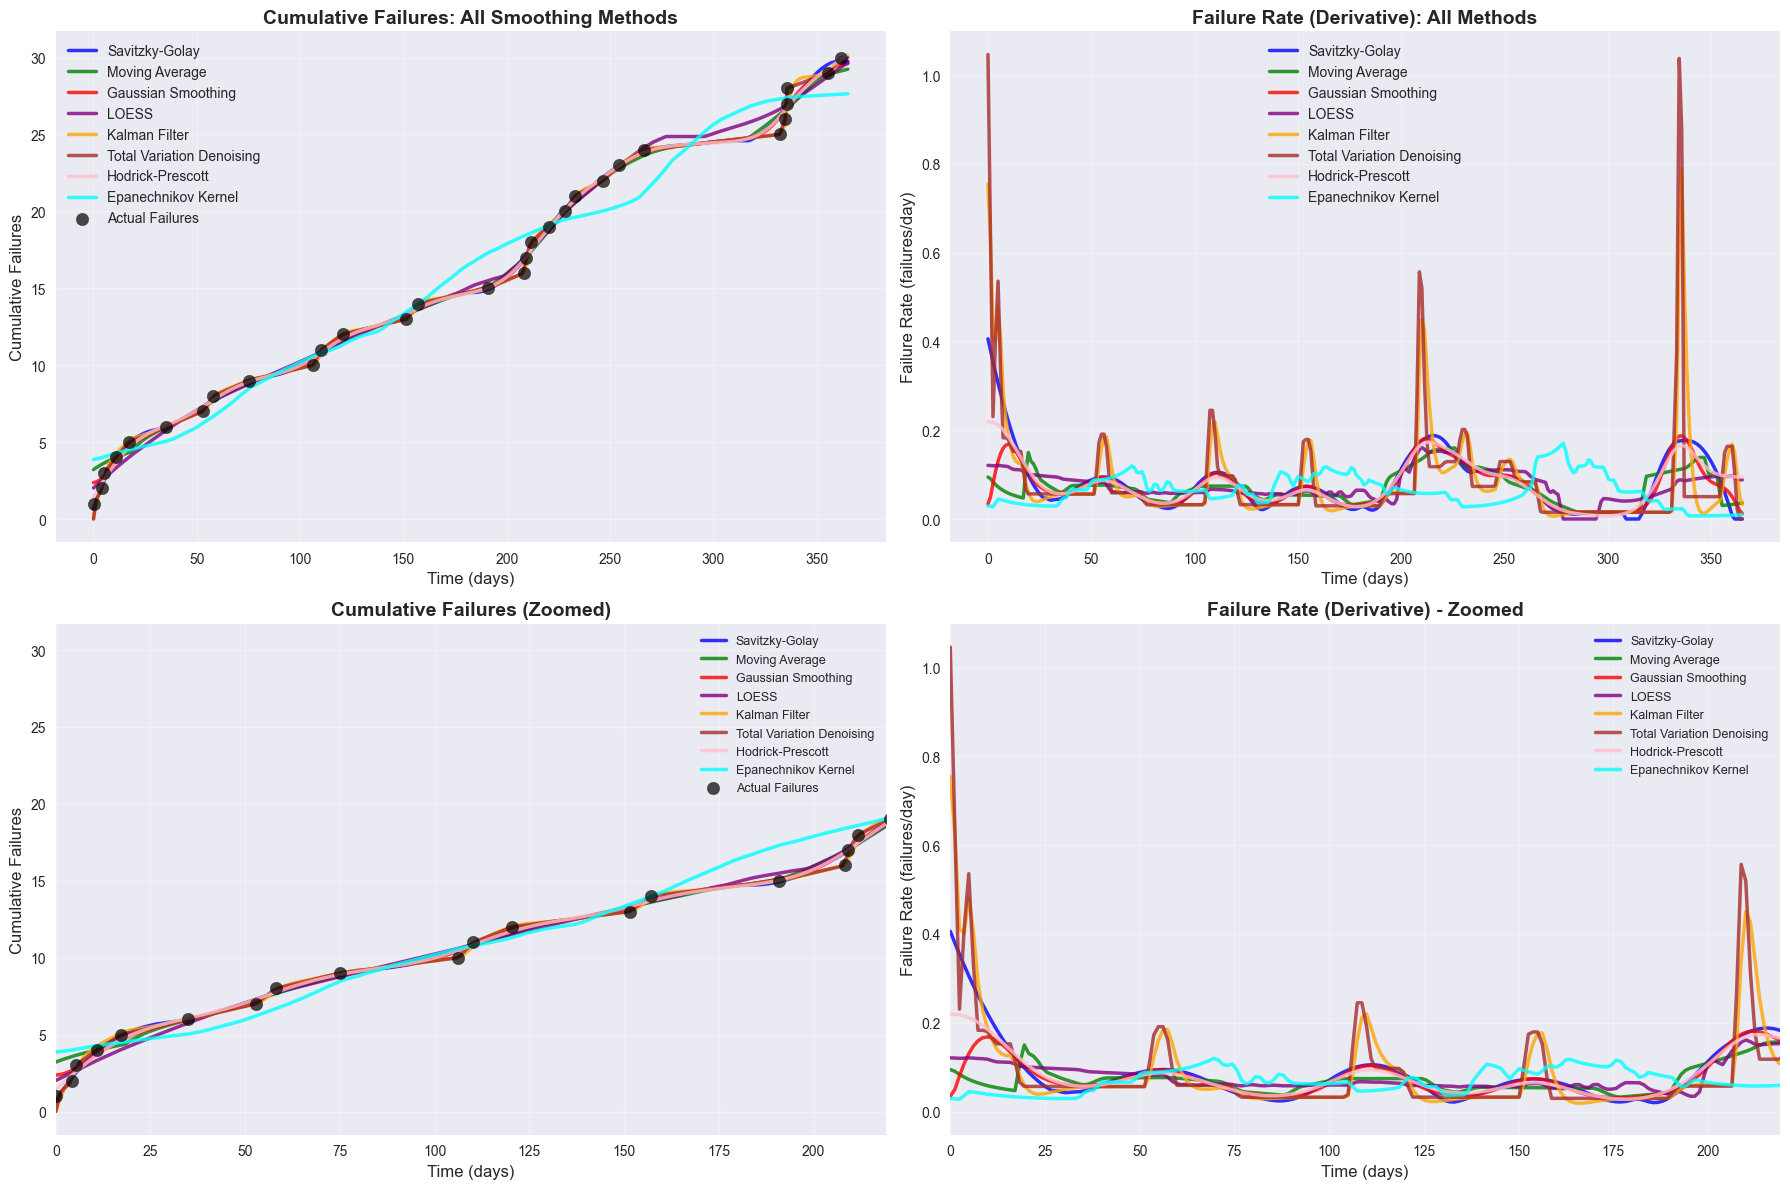


KEY INSIGHT: The derivative of cumulative failures = Failure Rate!


In [78]:
# Create comprehensive comparison plots
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Plot 1: Cumulative Failures - All Methods
ax = axes[0, 0]
colors = ['blue', 'green', 'red', 'purple', 'orange', 'brown', 'pink', 'cyan']
for idx, (name, result) in enumerate(results.items()):
    model = result['model']
    ax.plot(model.time_points, model.cumulative_smooth,
           linewidth=2.5, label=name, alpha=0.8, color=colors[idx % len(colors)])

ax.scatter(test_failures, actual_cumulative, color='black',
          s=80, zorder=5, label='Actual Failures', alpha=0.7)
ax.set_xlabel('Time (days)', fontsize=12)
ax.set_ylabel('Cumulative Failures', fontsize=12)
ax.set_title('Cumulative Failures: All Smoothing Methods', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Plot 2: Failure Rate (Derivative) - All Methods - THIS IS THE KEY PLOT!
ax = axes[0, 1]
for idx, (name, result) in enumerate(results.items()):
    model = result['model']
    ax.plot(model.time_points, model.failure_rate,
           linewidth=2.5, label=name, alpha=0.8, color=colors[idx % len(colors)])

ax.set_xlabel('Time (days)', fontsize=12)
ax.set_ylabel('Failure Rate (failures/day)', fontsize=12)
ax.set_title('Failure Rate (Derivative): All Methods', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Plot 3: Zoomed view of cumulative failures
ax = axes[1, 0]
for idx, (name, result) in enumerate(results.items()):
    model = result['model']
    ax.plot(model.time_points, model.cumulative_smooth,
           linewidth=2.5, label=name, alpha=0.8, color=colors[idx % len(colors)])

ax.scatter(test_failures, actual_cumulative, color='black',
          s=80, zorder=5, label='Actual Failures', alpha=0.7)
ax.set_xlabel('Time (days)', fontsize=12)
ax.set_ylabel('Cumulative Failures', fontsize=12)
ax.set_title('Cumulative Failures (Zoomed)', fontsize=14, fontweight='bold')
ax.set_xlim(0, test_censoring * 0.6)  # First 60% of time
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Plot 4: Zoomed view of failure rate
ax = axes[1, 1]
for idx, (name, result) in enumerate(results.items()):
    model = result['model']
    ax.plot(model.time_points, model.failure_rate,
           linewidth=2.5, label=name, alpha=0.8, color=colors[idx % len(colors)])

ax.set_xlabel('Time (days)', fontsize=12)
ax.set_ylabel('Failure Rate (failures/day)', fontsize=12)
ax.set_title('Failure Rate (Derivative) - Zoomed', fontsize=14, fontweight='bold')
ax.set_xlim(0, test_censoring * 0.6)  # First 60% of time
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("KEY INSIGHT: The derivative of cumulative failures = Failure Rate!")
print("="*70)


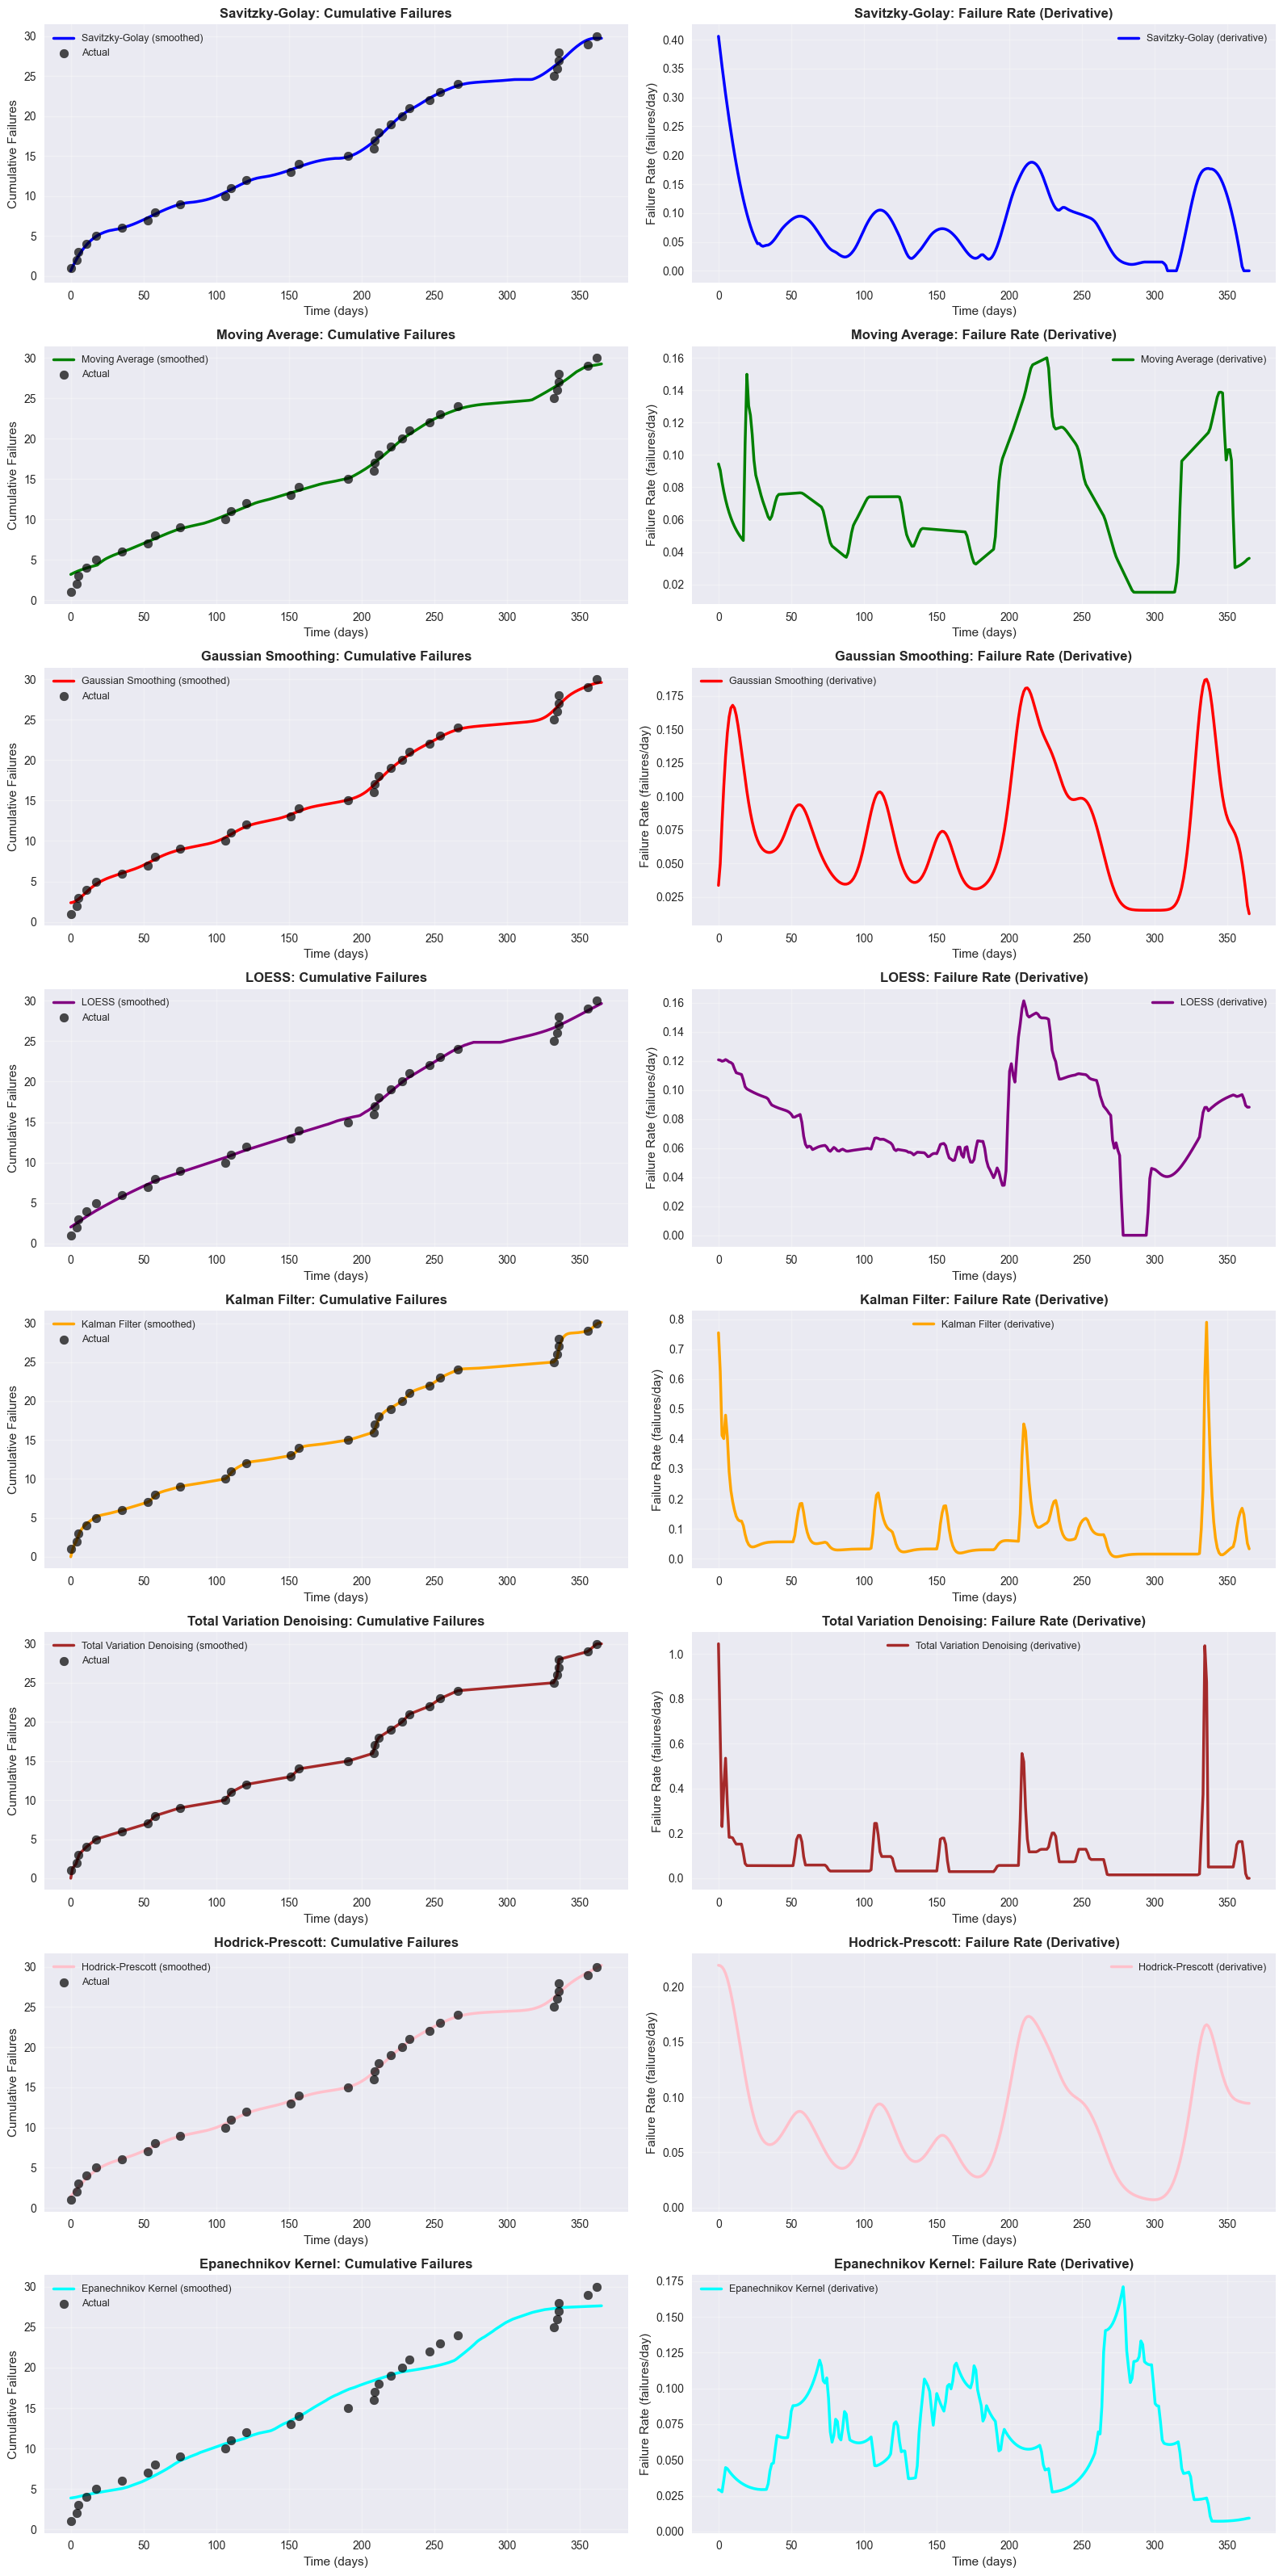

In [79]:
# Detailed comparison of each method side-by-side
n_methods = len(results)
fig, axes = plt.subplots(n_methods, 2, figsize=(16, 4 * n_methods))

for idx, (name, result) in enumerate(results.items()):
    model = result['model']
    
    # Left: Cumulative
    ax = axes[idx, 0]
    ax.plot(model.time_points, model.cumulative_smooth,
           linewidth=2.5, label=f'{name} (smoothed)', color=colors[idx % len(colors)])
    ax.scatter(test_failures, actual_cumulative, color='black',
              s=60, zorder=5, label='Actual', alpha=0.7)
    ax.set_xlabel('Time (days)', fontsize=11)
    ax.set_ylabel('Cumulative Failures', fontsize=11)
    ax.set_title(f'{name}: Cumulative Failures', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    
    # Right: Failure Rate (Derivative)
    ax = axes[idx, 1]
    ax.plot(model.time_points, model.failure_rate,
           linewidth=2.5, label=f'{name} (derivative)', color=colors[idx % len(colors)])
    ax.set_xlabel('Time (days)', fontsize=11)
    ax.set_ylabel('Failure Rate (failures/day)', fontsize=11)
    ax.set_title(f'{name}: Failure Rate (Derivative)', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Feature Extraction for ML

All methods extract similar features that can be used directly in ML models without needing parametric model parameters.


## Feature Descriptions

Below is a detailed explanation of each extracted feature and what it means for ML applications:

### Basic Statistics
- **`total_failures`**: Total number of failures observed over the observation period. Higher values indicate more frequent failures.
- **`total_time`**: Total observation time (in days). Used to normalize other time-based features.
- **`failures_per_unit_time`**: Average failure frequency (failures/day). Simple metric for overall reliability.

### Failure Rate Statistics
- **`avg_failure_rate`**: Mean failure rate over time (failures/day). Overall intensity of failures.
- **`std_failure_rate`**: Standard deviation of failure rate. Measures variability - higher values indicate more inconsistent failure patterns.
- **`peak_failure_rate`**: Maximum failure rate observed. Indicates worst-case failure intensity.
- **`failure_rate_cv`**: Coefficient of Variation (std/mean). Normalized variability measure:
  - CV < 0.5: Relatively stable failure rate
  - CV > 1.0: High variability (unstable)
  - CV = 0: Constant failure rate

### Failure Rate Distribution (Percentiles)
- **`failure_rate_p25`**: 25th percentile of failure rate. Lower quartile - 25% of time has failure rate below this.
- **`failure_rate_p50`**: 50th percentile (median) of failure rate. Middle value - half the time above/below.
- **`failure_rate_p75`**: 75th percentile of failure rate. Upper quartile - 25% of time has failure rate above this.
- **`failure_rate_p90`**: 90th percentile of failure rate. 90% of time has failure rate below this value.

### Trend Indicators
- **`failure_rate_slope`**: Linear trend of failure rate over time (failures/day²):
  - **Positive**: Failure rate increasing (degrading reliability)
  - **Negative**: Failure rate decreasing (improving reliability)
  - **Near zero**: Relatively constant failure rate
- **`failure_rate_trend_r2`**: R² of linear regression (0-1). Measures how well a linear trend fits:
  - **High R² (>0.5)**: Strong linear trend
  - **Low R² (<0.1)**: Weak or non-linear patterns
- **`failure_rate_acceleration`**: Rate of change of failure rate (second derivative). Measures how quickly the trend is changing:
  - **Positive**: Trend is accelerating (getting worse faster)
  - **Negative**: Trend is decelerating (improving more slowly)

### Temporal Comparison Features
- **`early_period_rate`**: Average failure rate in first half of observation period.
- **`late_period_rate`**: Average failure rate in second half of observation period.
- **`rate_change_ratio`**: Ratio of late/early period rates:
  - **> 1.0**: Failure rate increased (degrading)
  - **< 1.0**: Failure rate decreased (improving)
  - **= 1.0**: No change

### ML Interpretation Tips
- **For PM Effectiveness**: Compare `rate_change_ratio` before/after PM implementation. Values < 1.0 suggest PM is working.
- **For Predictive Models**: Use `failure_rate_slope` and `failure_rate_trend_r2` to detect trends. Low R² suggests need for non-linear models.
- **For Risk Assessment**: `peak_failure_rate` and `failure_rate_p90` indicate worst-case scenarios.
- **For Stability Analysis**: `failure_rate_cv` shows consistency. Lower CV = more predictable patterns.


Extracted Features for ML (all methods):
 total_failures  avg_failure_rate  std_failure_rate  failure_rate_slope  failure_rate_trend_r2  failure_rate_p25  failure_rate_p50  failure_rate_p75  failure_rate_p90  failure_rate_acceleration  total_time  failures_per_unit_time  early_period_rate  late_period_rate  rate_change_ratio  failure_rate_cv  peak_failure_rate                    method
      29.752267          0.080740          0.064889           -0.000095               0.023829          0.031158          0.069065          0.104659          0.169912                  -0.001144       365.0                0.081513           0.078645          0.082835           1.053279         0.803687           0.405849            Savitzky-Golay
      29.244235          0.071305          0.036274            0.000007               0.000367          0.045826          0.068241          0.097351          0.120983                  -0.000164       365.0                0.080121           0.063442          0.079

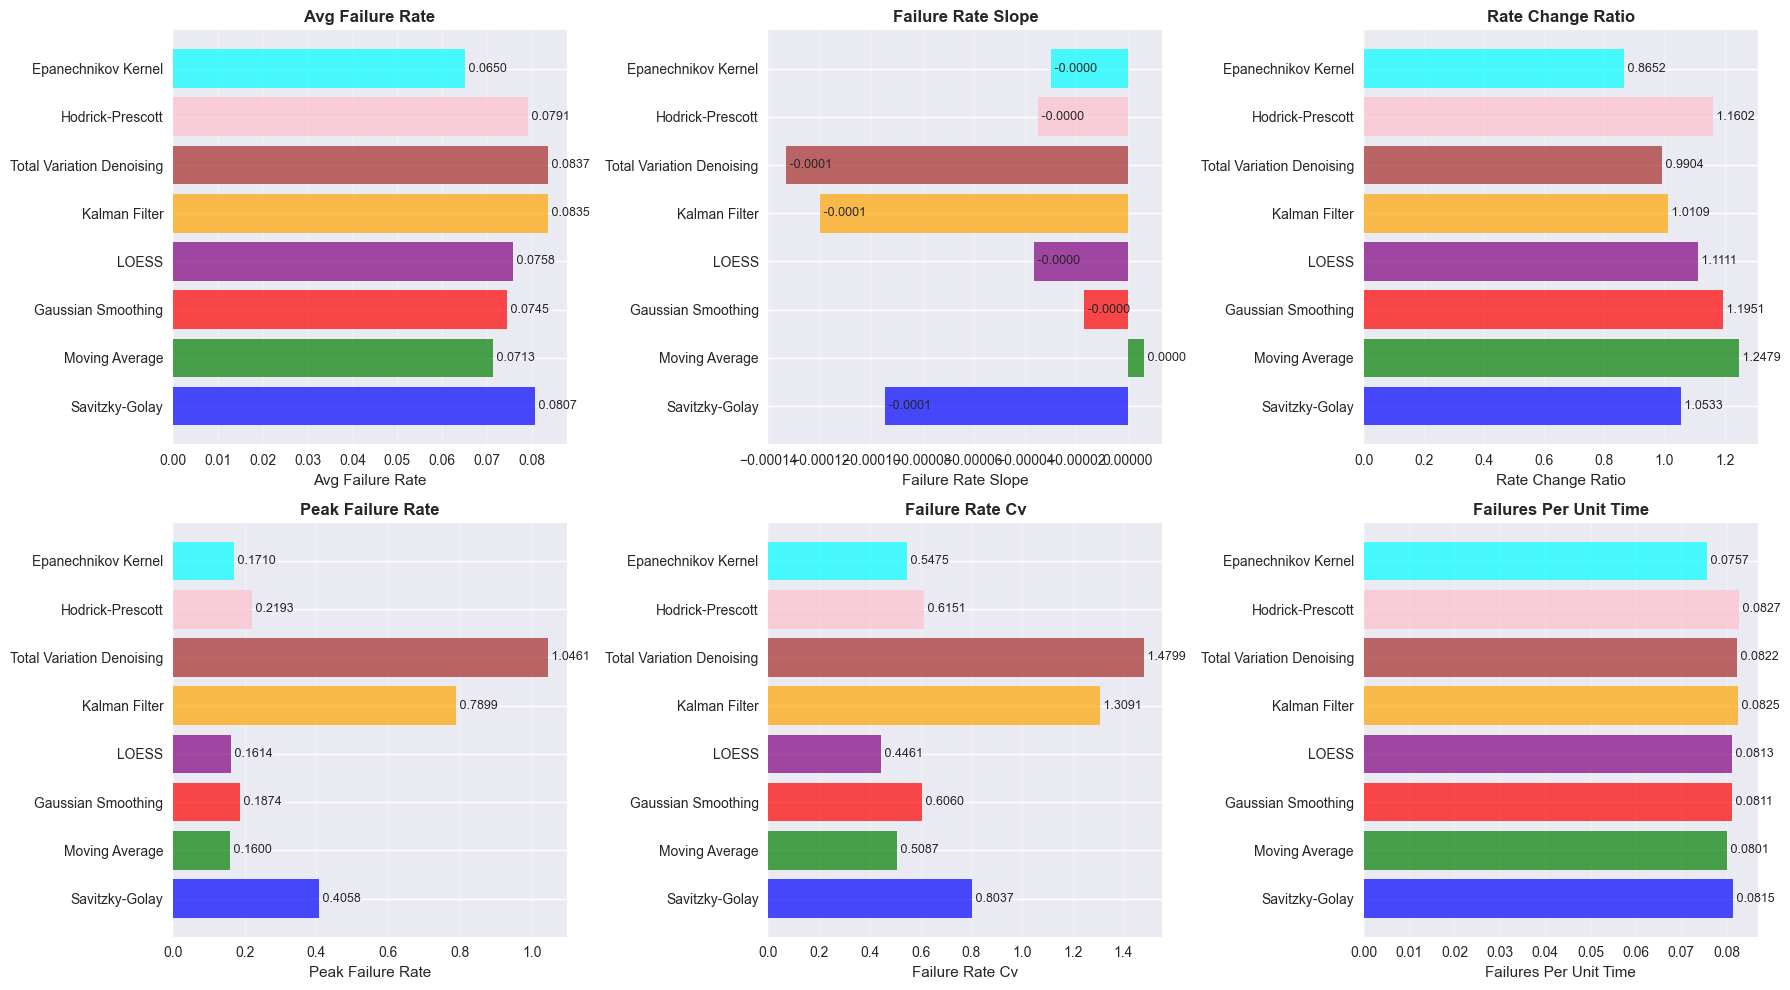

In [80]:
# Extract and compare features from all methods
all_features = []

for name, result in results.items():
    features = result['features'].copy()
    features['method'] = name
    all_features.append(features)

features_df = pd.DataFrame(all_features)
print("Extracted Features for ML (all methods):")
print("=" * 80)
print(features_df.to_string(index=False))

# Create a comparison visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Key features to compare
key_features = ['avg_failure_rate', 'failure_rate_slope', 'rate_change_ratio', 
                'peak_failure_rate', 'failure_rate_cv', 'failures_per_unit_time']

for idx, feat in enumerate(key_features):
    ax = axes[idx // 3, idx % 3]
    if feat in features_df.columns:
        values = features_df[feat].values
        methods = features_df['method'].values
        
        bars = ax.barh(methods, values, color=colors[:len(methods)], alpha=0.7)
        ax.set_xlabel(feat.replace('_', ' ').title(), fontsize=11)
        ax.set_title(f'{feat.replace("_", " ").title()}', fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3, axis='x')
        
        # Add value labels
        for i, (bar, val) in enumerate(zip(bars, values)):
            ax.text(val, i, f' {val:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()


## Advanced Time Series ML Method Comparison

For time series ML models (LSTM, RNN, ARIMA, Transformer, etc.), we evaluate methods based on:
1. **Time Series Smoothness** - How smooth is the failure rate series (critical for neural networks)
2. **Temporal Dependencies** - Strength of autocorrelation (important for ARIMA-like models)
3. **Signal Quality** - Signal-to-noise ratio (affects all time series models)
4. **Stationarity** - Variance stability over time (important for statistical models)
5. **Feature Completeness** - Ability to extract time series features


TIME SERIES ML METHOD COMPARISON
                           smoothness  temporal_dependencies  signal_quality  stationarity  feature_completeness   ml_score
Hodrick-Prescott             0.999430               0.614020        0.903480      0.966139                   1.0  85.965183
Epanechnikov Kernel          0.994043               0.652642        0.879767      0.594756                   1.0  80.917227
LOESS                        0.995552               0.578949        0.882754      0.697348                   1.0  80.350340
Moving Average               0.993382               0.596479        0.825685      0.660774                   1.0  79.121148
Savitzky-Golay               0.998481               0.527953        0.829773      0.749186                   1.0  78.626249
Gaussian Smoothing           0.998529               0.533377        0.806891      0.755592                   1.0  78.428872
Kalman Filter                0.961759               0.276119        0.608174      0.767404         

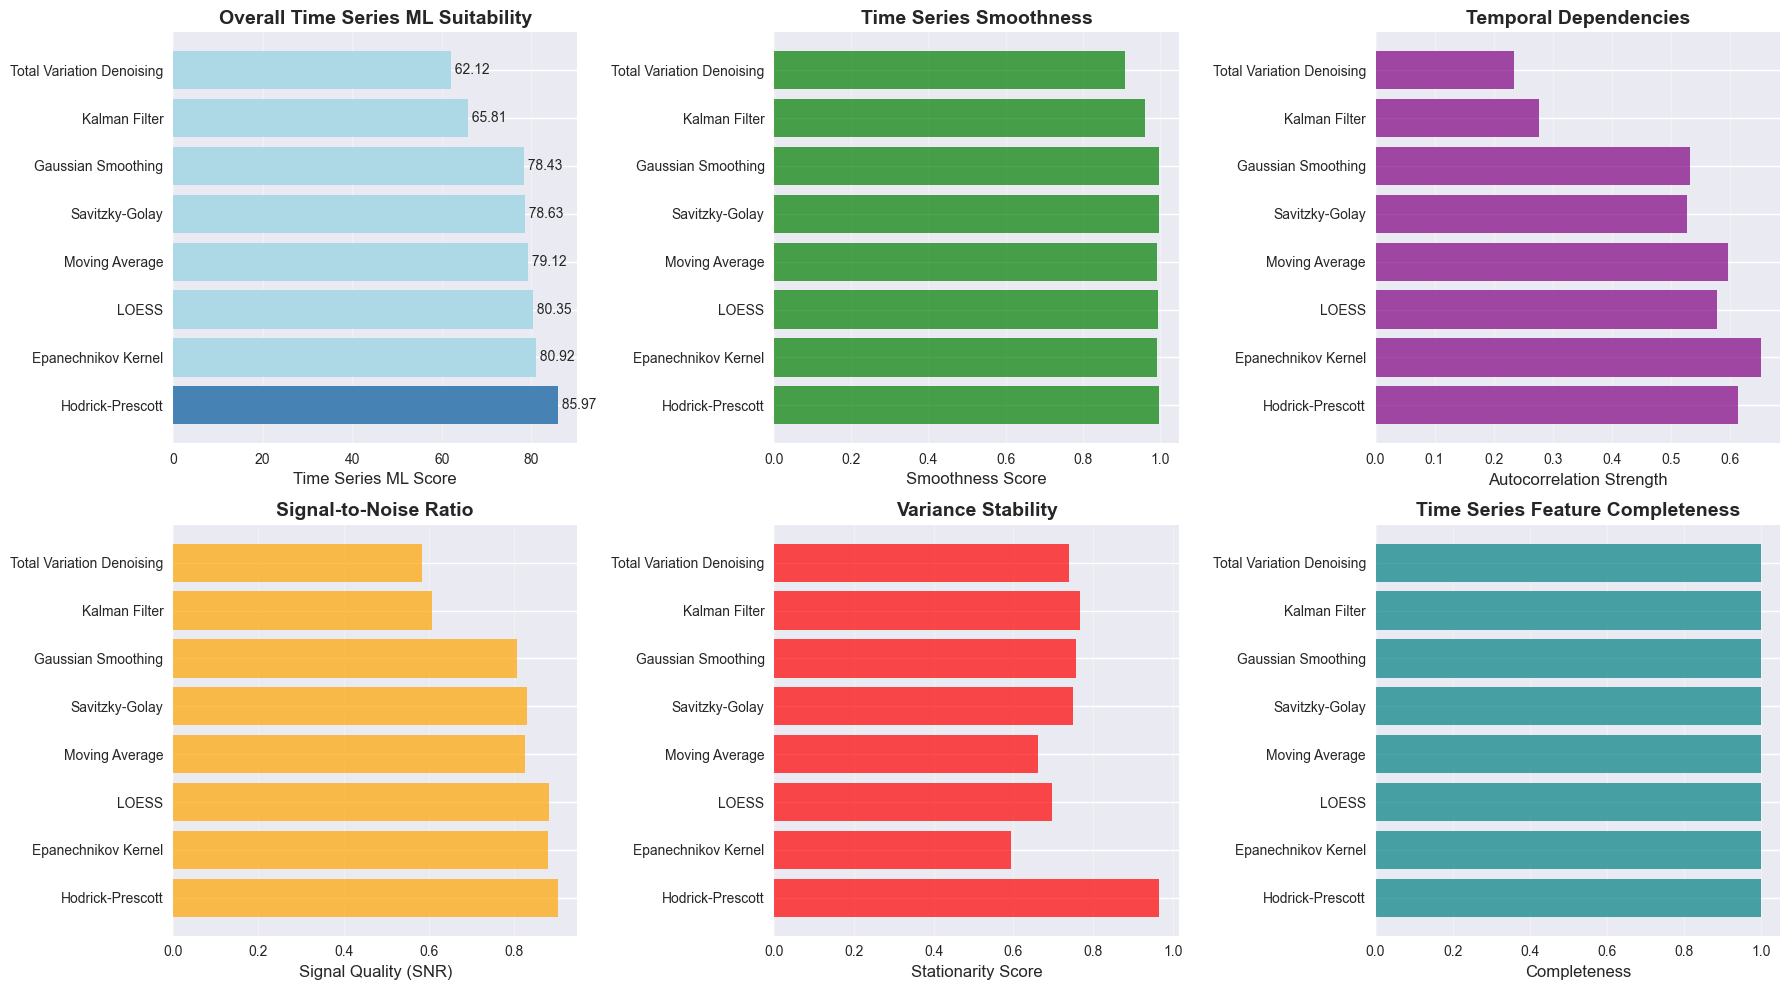


FINAL TIME SERIES ML RECOMMENDATION:
Best method for Time Series ML: Hodrick-Prescott
Time Series ML Score: 85.97/100
  - Smoothness: 0.9994
  - Temporal Dependencies: 0.6140
  - Signal Quality: 0.9035
  - Stationarity: 0.9661
  - Feature Completeness: 1.0000


In [81]:
# Advanced comparison for Time Series ML
def compare_methods_for_timeseries_ml(features_dict, models_dict):
    """
    Compare methods on Time Series ML-specific criteria:
    1. Time Series Smoothness - How smooth is the failure rate series (important for LSTM/RNN)
    2. Temporal Dependencies - Strength of autocorrelation (important for ARIMA-like models)
    3. Signal Quality - Signal-to-noise ratio (important for all time series models)
    4. Stationarity - How stationary the series is (important for statistical models)
    """
    comparison = {}
    
    for method_name, features in features_dict.items():
        metrics = {}
        model = models_dict[method_name]
        
        if not hasattr(model, 'failure_rate') or not model.fitted:
            continue
        
        failure_rate = model.failure_rate
        
        # 1. Time Series Smoothness (inverse of second derivative variance)
        # Lower variance in changes = smoother series = better for time series models
        if len(failure_rate) > 2:
            first_diff = np.diff(failure_rate)
            second_diff = np.diff(first_diff)
            smoothness = 1 / (1 + np.std(second_diff))  # Higher = smoother
        else:
            smoothness = 0
        metrics['smoothness'] = smoothness
        
        # 2. Temporal Dependencies (Autocorrelation strength)
        # Higher autocorrelation = stronger temporal patterns = better for time series models
        autocorr_sum = 0
        autocorr_count = 0
        for lag in [1, 7, 14, 30]:
            if len(failure_rate) > lag:
                try:
                    acf = np.corrcoef(failure_rate[:-lag], failure_rate[lag:])[0, 1]
                    if not np.isnan(acf):
                        autocorr_sum += abs(acf)
                        autocorr_count += 1
                except:
                    pass
        metrics['temporal_dependencies'] = autocorr_sum / autocorr_count if autocorr_count > 0 else 0
        
        # 3. Signal Quality (Signal-to-Noise Ratio)
        # Higher SNR = cleaner signal = better for ML models
        if len(failure_rate) > 1:
            signal_power = np.var(failure_rate)
            # Estimate noise as variance of detrended series
            if len(failure_rate) > 10:
                trend = pd.Series(failure_rate).rolling(
                    window=min(30, len(failure_rate)//4), center=True, min_periods=1
                ).mean()
                noise = failure_rate - trend.values
                noise_power = np.var(noise)
                snr = signal_power / (noise_power + 1e-10)
                metrics['signal_quality'] = 1 / (1 + 1/snr)  # Normalized
            else:
                metrics['signal_quality'] = 0.5
        else:
            metrics['signal_quality'] = 0
        
        # 4. Stationarity (variance stability over time)
        # More stationary = better for ARIMA/statistical models
        if len(failure_rate) > 10:
            # Split into segments and compare variance
            n_segments = 3
            segment_size = len(failure_rate) // n_segments
            segment_vars = []
            for i in range(n_segments):
                start = i * segment_size
                end = (i + 1) * segment_size if i < n_segments - 1 else len(failure_rate)
                segment_vars.append(np.var(failure_rate[start:end]))
            # Lower variance in segment variances = more stationary
            stationarity = 1 / (1 + np.std(segment_vars) / (np.mean(segment_vars) + 1e-10))
        else:
            stationarity = 0.5
        metrics['stationarity'] = stationarity
        
        # 5. Feature Completeness (for time series features)
        # Check if time series features can be extracted
        try:
            ts_features = model.extract_timeseries_features()
            completeness = 1.0 if 'timeseries_data' in ts_features else 0.0
        except:
            completeness = 0.0
        metrics['feature_completeness'] = completeness
        
        # Weighted Time Series ML score
        # For time series ML, smoothness and temporal dependencies are most important
        ml_score = (
            metrics['smoothness'] * 0.30 +
            metrics['temporal_dependencies'] * 0.30 +
            metrics['signal_quality'] * 0.20 +
            metrics['stationarity'] * 0.15 +
            metrics['feature_completeness'] * 0.05
        ) * 100
        
        comparison[method_name] = {
            **metrics,
            'ml_score': ml_score
        }
    
    return comparison

# Run time series ML comparison
ml_comparison = compare_methods_for_timeseries_ml(
    {name: result['features'] for name, result in results.items()},
    {name: result['model'] for name, result in results.items()}
)

ml_df = pd.DataFrame(ml_comparison).T
ml_df = ml_df.sort_values('ml_score', ascending=False)

print("="*80)
print("TIME SERIES ML METHOD COMPARISON")
print("="*80)
print(ml_df.to_string())

# Visualize
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Overall ML Score
ax = axes[0, 0]
methods = ml_df.index
scores = ml_df['ml_score'].values
bars = ax.barh(methods, scores, color=['steelblue' if s == max(scores) else 'lightblue' for s in scores])
ax.set_xlabel('Time Series ML Score', fontsize=12)
ax.set_title('Overall Time Series ML Suitability', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
for bar, score in zip(bars, scores):
    ax.text(score, bar.get_y() + bar.get_height()/2, 
           f' {score:.2f}', va='center', fontsize=10)

# 2. Smoothness
ax = axes[0, 1]
ax.barh(methods, ml_df['smoothness'].values, color='green', alpha=0.7)
ax.set_xlabel('Smoothness Score', fontsize=12)
ax.set_title('Time Series Smoothness', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

# 3. Temporal Dependencies
ax = axes[0, 2]
ax.barh(methods, ml_df['temporal_dependencies'].values, color='purple', alpha=0.7)
ax.set_xlabel('Autocorrelation Strength', fontsize=12)
ax.set_title('Temporal Dependencies', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

# 4. Signal Quality
ax = axes[1, 0]
ax.barh(methods, ml_df['signal_quality'].values, color='orange', alpha=0.7)
ax.set_xlabel('Signal Quality (SNR)', fontsize=12)
ax.set_title('Signal-to-Noise Ratio', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

# 5. Stationarity
ax = axes[1, 1]
ax.barh(methods, ml_df['stationarity'].values, color='red', alpha=0.7)
ax.set_xlabel('Stationarity Score', fontsize=12)
ax.set_title('Variance Stability', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

# 6. Feature Completeness
ax = axes[1, 2]
ax.barh(methods, ml_df['feature_completeness'].values, color='teal', alpha=0.7)
ax.set_xlabel('Completeness', fontsize=12)
ax.set_title('Time Series Feature Completeness', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("FINAL TIME SERIES ML RECOMMENDATION:")
print("="*80)
best_ml = ml_df.index[0]
print(f"Best method for Time Series ML: {best_ml}")
print(f"Time Series ML Score: {ml_df.loc[best_ml, 'ml_score']:.2f}/100")
print(f"  - Smoothness: {ml_df.loc[best_ml, 'smoothness']:.4f}")
print(f"  - Temporal Dependencies: {ml_df.loc[best_ml, 'temporal_dependencies']:.4f}")
print(f"  - Signal Quality: {ml_df.loc[best_ml, 'signal_quality']:.4f}")
print(f"  - Stationarity: {ml_df.loc[best_ml, 'stationarity']:.4f}")
print(f"  - Feature Completeness: {ml_df.loc[best_ml, 'feature_completeness']:.4f}")


## Extract Time Series Features

Now let's extract time series features from the best method for use in time series ML models.


## Autocorrelation Analysis

**Autocorrelation** measures how well a time series correlates with itself at different time lags. This is crucial for:
- **Selecting optimal lag features** for ML models
- **Understanding temporal dependencies** in failure rates
- **Identifying periodic patterns** (weekly, monthly cycles)
- **Determining if ARIMA models** are appropriate

### What Autocorrelation Tells Us

- **ACF (Autocorrelation Function)**: Shows correlation at different lags
  - High ACF at lag k → failure rate at time t is correlated with time t-k
  - Useful for understanding overall dependencies
  
- **PACF (Partial Autocorrelation Function)**: Shows direct correlation after removing indirect effects
  - High PACF at lag k → direct dependency at that lag
  - Better for selecting lags for AR models

### How to Interpret

- **Significant autocorrelation** (outside confidence bands) → Use that lag as a feature
- **Decaying autocorrelation** → Short-term dependencies (use recent lags)
- **Periodic spikes** → Seasonal patterns (use those specific lags)
- **No autocorrelation** → Series is white noise (may need differencing)


In [82]:
def analyze_autocorrelation(failure_rate, time_points, method_name, max_lag=None):
    """
    Comprehensive autocorrelation analysis.
    
    Returns:
    --------
    acf_results : dict with ACF values, confidence intervals, significant lags
    pacf_results : dict with PACF values, confidence intervals, significant lags
    """
    if max_lag is None:
        max_lag = min(50, len(failure_rate) // 2)
    
    results = {}
    
    if STATSMODELS_AVAILABLE:
        # ACF Analysis
        acf_values, confint_acf = acf(failure_rate, nlags=max_lag, alpha=0.05, fft=True)
        
        # Find significant ACF lags (outside confidence interval)
        significant_acf_lags = []
        for lag in range(1, len(acf_values)):
            if abs(acf_values[lag]) > abs(confint_acf[lag][0]):
                significant_acf_lags.append(lag)
        
        results['acf'] = {
            'values': acf_values,
            'confidence_intervals': confint_acf,
            'significant_lags': significant_acf_lags,
            'max_significant_lag': max(significant_acf_lags) if significant_acf_lags else 0
        }
        
        # PACF Analysis
        pacf_values, confint_pacf = pacf(failure_rate, nlags=max_lag, alpha=0.05)
        
        # Find significant PACF lags
        significant_pacf_lags = []
        for lag in range(1, len(pacf_values)):
            if abs(pacf_values[lag]) > abs(confint_pacf[lag][0]):
                significant_pacf_lags.append(lag)
        
        results['pacf'] = {
            'values': pacf_values,
            'confidence_intervals': confint_pacf,
            'significant_lags': significant_pacf_lags,
            'max_significant_lag': max(significant_pacf_lags) if significant_pacf_lags else 0
        }
        
        # Autocorrelation strength (average absolute ACF)
        results['autocorr_strength'] = np.mean(np.abs(acf_values[1:]))
        
        # Lag selection recommendations - More selective approach
        # Strategy: Prioritize lags with strong direct dependencies (PACF) and high correlation
        
        # 1. Rank PACF lags by absolute correlation strength (most important first)
        pacf_ranked = [(lag, abs(pacf_values[lag])) for lag in significant_pacf_lags]
        pacf_ranked.sort(key=lambda x: x[1], reverse=True)
        
        # 2. Take top 5-7 most significant PACF lags (or those with |PACF| > 0.3)
        min_pacf_threshold = 0.3
        top_pacf_lags = [lag for lag, strength in pacf_ranked 
                        if strength > min_pacf_threshold][:7]
        # If we don't have enough with threshold, take top 5 by strength
        if len(top_pacf_lags) < 3:
            top_pacf_lags = [lag for lag, _ in pacf_ranked[:5]]
        
        # 3. Find lags significant in BOTH ACF and PACF (strongest signal)
        both_significant = list(set(significant_pacf_lags) & set(significant_acf_lags))
        both_significant.sort()
        
        # 4. Combine: prioritize lags significant in both, then top PACF lags
        # Always include lag 1 if significant (most recent value is usually important)
        recommended_lags = []
        if 1 in significant_pacf_lags or 1 in significant_acf_lags:
            recommended_lags.append(1)
        
        # Add lags significant in both (up to 3)
        for lag in both_significant[:3]:
            if lag not in recommended_lags:
                recommended_lags.append(lag)
        
        # Add top PACF lags (up to 5 total)
        for lag in top_pacf_lags:
            if lag not in recommended_lags and len(recommended_lags) < 7:
                recommended_lags.append(lag)
        
        recommended_lags.sort()
        results['recommended_lags'] = recommended_lags
        results['lag_selection_info'] = {
            'top_pacf_lags': top_pacf_lags,
            'both_significant': both_significant,
            'selection_strategy': 'Selective: Top PACF + Both-significant lags'
        }
        
    else:
        # Fallback: simple correlation-based autocorrelation
        acf_simple = []
        for lag in range(1, min(max_lag, len(failure_rate) // 2)):
            if len(failure_rate) > lag:
                try:
                    corr = np.corrcoef(failure_rate[:-lag], failure_rate[lag:])[0, 1]
                    acf_simple.append((lag, corr if not np.isnan(corr) else 0))
                except:
                    acf_simple.append((lag, 0))
        
        # More selective: only top 5-7 lags with correlation > 0.3
        acf_simple.sort(key=lambda x: abs(x[1]), reverse=True)
        # Filter by minimum correlation threshold and limit to top 7
        significant_lags = [lag for lag, corr in acf_simple if abs(corr) > 0.3][:7]
        # If not enough with threshold, take top 5 by strength
        if len(significant_lags) < 3:
            significant_lags = [lag for lag, _ in acf_simple[:5]]
        
        results['acf'] = {
            'values': np.array([corr for _, corr in acf_simple]),
            'significant_lags': significant_lags,
            'simple_mode': True
        }
        results['recommended_lags'] = significant_lags
        results['lag_selection_info'] = {
            'selection_strategy': 'Selective: Top 5-7 lags with |corr| > 0.3'
        }
    
    return results

# Analyze autocorrelation for all methods
autocorr_analysis = {}

print("="*80)
print("AUTOCORRELATION ANALYSIS FOR ALL METHODS")
print("="*80)

for name, result in results.items():
    model = result['model']
    if hasattr(model, 'failure_rate') and model.fitted:
        analysis = analyze_autocorrelation(
            model.failure_rate, 
            model.time_points, 
            name
        )
        autocorr_analysis[name] = analysis
        
        print(f"\n{name}:")
        if 'acf' in analysis:
            if 'significant_lags' in analysis['acf']:
                n_sig_acf = len(analysis['acf']['significant_lags'])
                print(f"  Significant ACF lags: {n_sig_acf} total (showing first 10: {analysis['acf']['significant_lags'][:10]})")
            if 'autocorr_strength' in analysis:
                print(f"  Autocorrelation strength: {analysis['autocorr_strength']:.4f}")
        if 'pacf' in analysis and 'significant_lags' in analysis['pacf']:
            n_sig_pacf = len(analysis['pacf']['significant_lags'])
            print(f"  Significant PACF lags: {n_sig_pacf} total (showing first 10: {analysis['pacf']['significant_lags'][:10]})")
        if 'recommended_lags' in analysis:
            print(f"  → Recommended lags for ML (selective): {analysis['recommended_lags']}")
            if 'lag_selection_info' in analysis:
                info = analysis['lag_selection_info']
                print(f"    Selection strategy: {info.get('selection_strategy', 'N/A')}")
                if 'both_significant' in info and info['both_significant']:
                    print(f"    Lags significant in both ACF & PACF: {info['both_significant'][:5]}")


AUTOCORRELATION ANALYSIS FOR ALL METHODS

Savitzky-Golay:
  Significant ACF lags: 12 total (showing first 10: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
  Autocorrelation strength: 0.2300
  Significant PACF lags: 1 total (showing first 10: [1])
  → Recommended lags for ML (selective): [1]
    Selection strategy: Selective: Top PACF + Both-significant lags
    Lags significant in both ACF & PACF: [1]

Moving Average:
  Significant ACF lags: 18 total (showing first 10: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
  Autocorrelation strength: 0.3940
  Significant PACF lags: 25 total (showing first 10: [1, 3, 5, 7, 9, 10, 12, 14, 17, 19])
  → Recommended lags for ML (selective): [1, 3, 5, 9, 23, 30, 39]
    Selection strategy: Selective: Top PACF + Both-significant lags
    Lags significant in both ACF & PACF: [1, 3, 5, 7, 9]

Gaussian Smoothing:
  Significant ACF lags: 14 total (showing first 10: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
  Autocorrelation strength: 0.3086
  Significant PACF lags: 1 total (showing first 

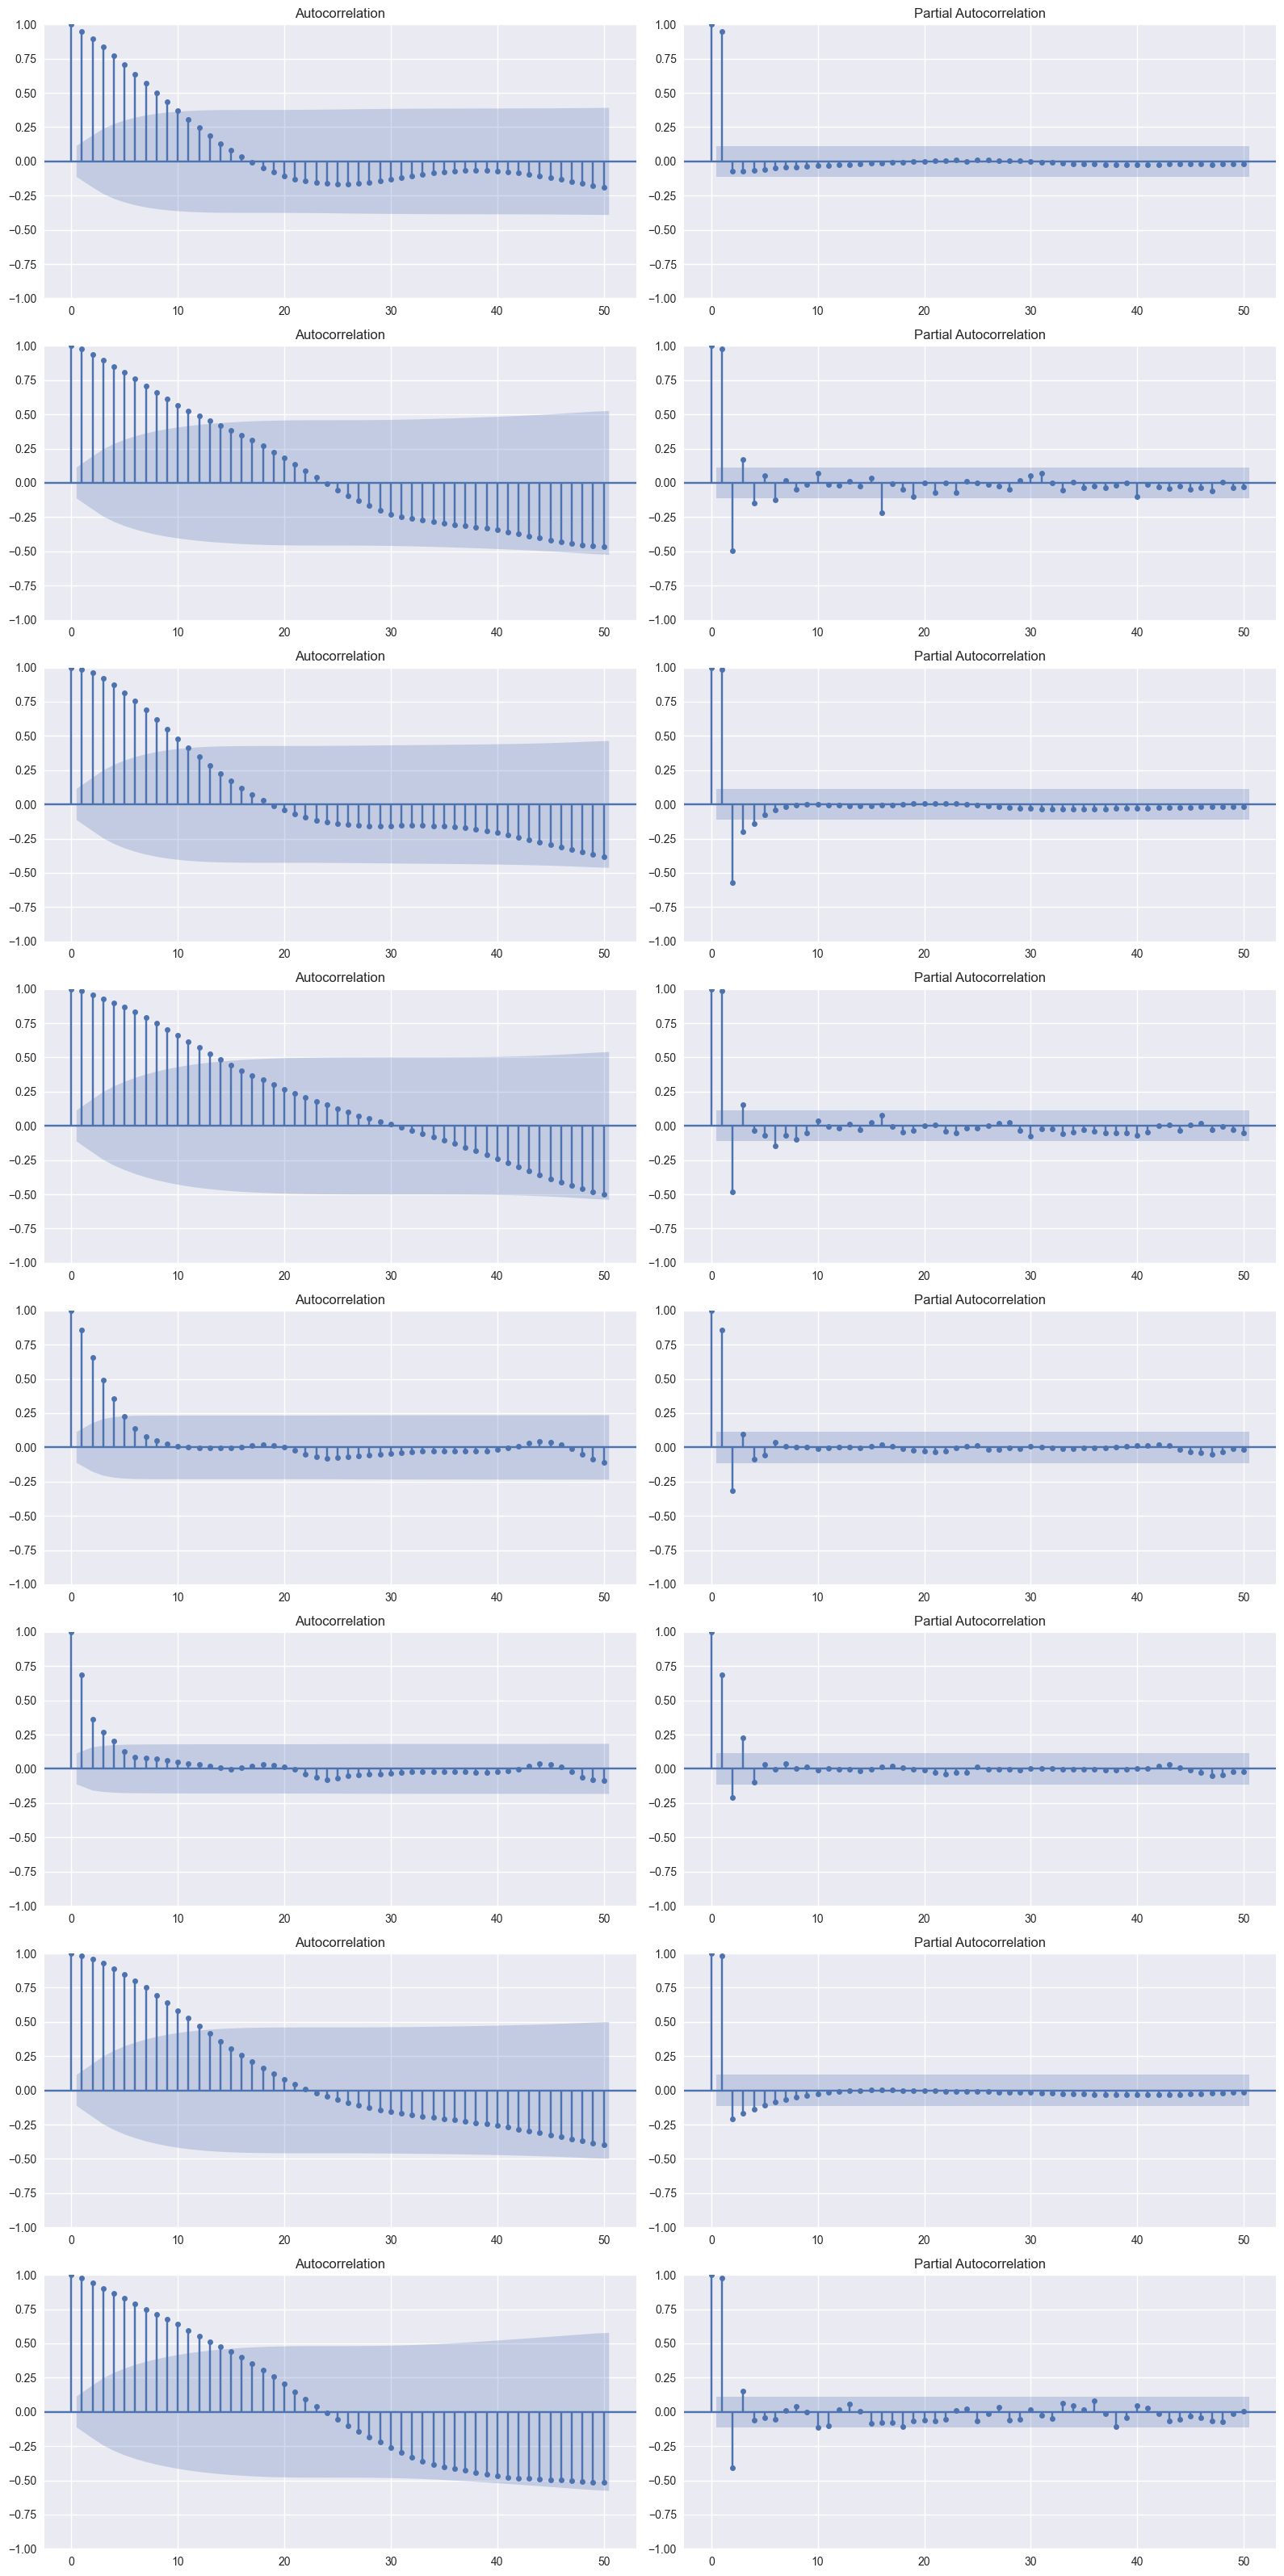

In [83]:
# Visualize ACF and PACF for all methods
if STATSMODELS_AVAILABLE:
    n_methods = len(autocorr_analysis)
    fig, axes = plt.subplots(n_methods, 2, figsize=(16, 4 * n_methods))
    
    if n_methods == 1:
        axes = axes.reshape(1, -1)
    
    for idx, (name, analysis) in enumerate(autocorr_analysis.items()):
        model = results[name]['model']
        failure_rate = model.failure_rate
        
        # ACF Plot
        ax = axes[idx, 0]
        if 'simple_mode' not in analysis['acf']:
            plot_acf(failure_rate, lags=min(50, len(failure_rate)//2), ax=ax, alpha=0.05)
        else:
            # Simple ACF plot
            lags = range(1, len(analysis['acf']['values']) + 1)
            ax.bar(lags, analysis['acf']['values'], width=0.8, alpha=0.7)
            ax.axhline(y=0.2, color='r', linestyle='--', alpha=0.5, label='Threshold')
            ax.axhline(y=-0.2, color='r', linestyle='--', alpha=0.5)
            ax.set_xlabel('Lag', fontsize=11)
            ax.set_ylabel('ACF', fontsize=11)
            ax.set_title(f'{name}: Autocorrelation Function (ACF)', fontsize=12, fontweight='bold')
            ax.legend()
            ax.grid(True, alpha=0.3)
        
        # PACF Plot
        ax = axes[idx, 1]
        if 'pacf' in analysis and 'simple_mode' not in analysis.get('acf', {}):
            plot_pacf(failure_rate, lags=min(50, len(failure_rate)//2), ax=ax, alpha=0.05)
        else:
            # Simple correlation at different lags
            max_lag = min(30, len(failure_rate) // 2)
            pacf_simple = []
            for lag in range(1, max_lag + 1):
                if len(failure_rate) > lag:
                    try:
                        corr = np.corrcoef(failure_rate[:-lag], failure_rate[lag:])[0, 1]
                        pacf_simple.append(corr if not np.isnan(corr) else 0)
                    except:
                        pacf_simple.append(0)
            
            ax.bar(range(1, len(pacf_simple) + 1), pacf_simple, width=0.8, alpha=0.7, color='orange')
            ax.axhline(y=0.2, color='r', linestyle='--', alpha=0.5, label='Threshold')
            ax.axhline(y=-0.2, color='r', linestyle='--', alpha=0.5)
            ax.set_xlabel('Lag', fontsize=11)
            ax.set_ylabel('PACF', fontsize=11)
            ax.set_title(f'{name}: Partial Autocorrelation Function (PACF)', fontsize=12, fontweight='bold')
            ax.legend()
            ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("\nNote: Install statsmodels for detailed ACF/PACF plots: pip install statsmodels")
    print("Using simple correlation-based analysis instead.")


## How to Use Autocorrelation for Lag Selection

Based on the autocorrelation analysis above, here's how to choose optimal lags:

### Our Selective Approach (Implemented Above)

The analysis now uses a **selective lag selection strategy** that avoids recommending too many lags:

1. **Prioritize Strong Direct Dependencies (PACF)**
   - Rank PACF lags by absolute correlation strength
   - Only include lags with |PACF| > 0.3 (strong correlation threshold)
   - Limit to top 5-7 most significant PACF lags

2. **Prioritize Lags Significant in Both ACF and PACF**
   - These represent the strongest signals (both direct and indirect correlation)
   - Up to 3 such lags are included

3. **Always Include Lag 1** (if significant)
   - The most recent value is usually the most informative

4. **Maximum 7 Lags Total**
   - Prevents feature explosion while maintaining predictive power

### Why This Approach?

- **Too many lags** → Overfitting, redundant features, slower training
- **Too few lags** → Missing important temporal patterns
- **Selective approach** → Balances model performance with feature efficiency

### Alternative Strategies (Manual Override)

If you want to customize lag selection:
- Start with PACF significant lags (direct dependencies)
- Add top ACF lags that aren't already included
- Add domain-specific lags (e.g., weekly, monthly if relevant)
- Best for: Comprehensive feature sets

### Strategy 4: Use Autocorrelation Strength
- If autocorrelation strength > 0.3: Strong temporal dependencies → use more lags
- If autocorrelation strength < 0.1: Weak dependencies → focus on recent lags only


In [84]:
# Compare recommended lags across methods
print("="*80)
print("LAG SELECTION COMPARISON")
print("="*80)

lag_comparison = {}
for name, analysis in autocorr_analysis.items():
    if 'recommended_lags' in analysis:
        lag_comparison[name] = analysis['recommended_lags']
        print(f"\n{name}:")
        print(f"  Recommended lags: {analysis['recommended_lags']}")
        if 'acf' in analysis and 'autocorr_strength' in analysis:
            strength = analysis['autocorr_strength']
            print(f"  Autocorrelation strength: {strength:.4f}")
            if strength > 0.3:
                print(f"  → Strong temporal dependencies - use more lags")
            elif strength > 0.1:
                print(f"  → Moderate temporal dependencies - use moderate lags")
            else:
                print(f"  → Weak temporal dependencies - use few recent lags")

# Find common lags across all methods (most robust)
if len(lag_comparison) > 1:
    all_lags = [set(lags) for lags in lag_comparison.values()]
    common_lags = set.intersection(*all_lags) if all_lags else set()
    union_lags = set.union(*all_lags) if all_lags else set()
    
    print("\n" + "="*80)
    print("ROBUST LAG SELECTION")
    print("="*80)
    print(f"Common lags across all methods: {sorted(common_lags)}")
    print(f"Union of all recommended lags: {sorted(union_lags)}")
    print(f"\nRecommendation:")
    if common_lags:
        print(f"  → Use common lags for robust features: {sorted(common_lags)}")
    else:
        print(f"  → Methods differ significantly - use method-specific lags")
        print(f"  → Or use union of all lags: {sorted(union_lags)}")


LAG SELECTION COMPARISON

Savitzky-Golay:
  Recommended lags: [1]
  Autocorrelation strength: 0.2300
  → Moderate temporal dependencies - use moderate lags

Moving Average:
  Recommended lags: [1, 3, 5, 9, 23, 30, 39]
  Autocorrelation strength: 0.3940
  → Strong temporal dependencies - use more lags

Gaussian Smoothing:
  Recommended lags: [1]
  Autocorrelation strength: 0.3086
  → Strong temporal dependencies - use more lags

LOESS:
  Recommended lags: [1, 3, 5, 13, 25, 37, 38]
  Autocorrelation strength: 0.3807
  → Strong temporal dependencies - use more lags

Kalman Filter:
  Recommended lags: [1, 3]
  Autocorrelation strength: 0.0845
  → Weak temporal dependencies - use few recent lags

Total Variation Denoising:
  Recommended lags: [1, 3]
  Autocorrelation strength: 0.0653
  → Weak temporal dependencies - use few recent lags

Hodrick-Prescott:
  Recommended lags: [1]
  Autocorrelation strength: 0.3449
  → Strong temporal dependencies - use more lags

Epanechnikov Kernel:
  Recomm

## Extract Time Series Features with Autocorrelation-Based Lag Selection

Now let's extract time series features using the autocorrelation-recommended lags instead of fixed sequential lags.


In [85]:
# Extract time series features using autocorrelation-recommended lags
timeseries_features_acf = {}

for name, result in results.items():
    model = result['model']
    if name in autocorr_analysis and hasattr(model, 'extract_timeseries_features'):
        try:
            # Get recommended lags from autocorrelation analysis
            recommended_lags = autocorr_analysis[name].get('recommended_lags', [1, 2, 3, 4, 5])
            
            # If no recommended lags, use default
            if not recommended_lags:
                recommended_lags = [1, 2, 3, 4, 5]
            
            # Extract features with custom lag selection
            # We'll create a modified version that uses recommended lags
            failure_rate = model.failure_rate
            time_points = model.time_points
            cumulative_smooth = model.cumulative_smooth
            
            features = {}
            features['timeseries_data'] = {
                'time_points': time_points.copy(),
                'failure_rate': failure_rate.copy(),
                'cumulative_failures': cumulative_smooth.copy()
            }
            
            # Add autocorrelation-recommended lag features
            for lag in recommended_lags[:15]:  # Limit to top 15 to avoid too many features
                if len(failure_rate) > lag:
                    lag_values = np.roll(failure_rate, lag)
                    lag_values[:lag] = np.nan
                    features[f'failure_rate_lag_{lag}'] = lag_values
            
            # Also add sequential lags 1-3 (always useful)
            for lag in [1, 2, 3]:
                if lag not in recommended_lags and len(failure_rate) > lag:
                    lag_values = np.roll(failure_rate, lag)
                    lag_values[:lag] = np.nan
                    features[f'failure_rate_lag_{lag}'] = lag_values
            
            # Add rolling statistics
            window_sizes = [7, 14, 30]
            for window in window_sizes:
                if len(failure_rate) >= window:
                    rolling_mean = pd.Series(failure_rate).rolling(window=window, min_periods=1).mean()
                    rolling_std = pd.Series(failure_rate).rolling(window=window, min_periods=1).std()
                    features[f'rolling_mean_{window}'] = rolling_mean.values
                    features[f'rolling_std_{window}'] = rolling_std.values
            
            # Add autocorrelation features
            features['autocorrelation'] = autocorr_analysis[name].get('acf', {}).get('significant_lags', [])
            features['autocorr_strength'] = autocorr_analysis[name].get('autocorr_strength', 0)
            features['recommended_lags'] = recommended_lags
            
            timeseries_features_acf[name] = features
            
            print(f"✓ {name}: Extracted features with {len(recommended_lags)} autocorrelation-recommended lags")
            print(f"  Lags used: {sorted(set([lag for lag in recommended_lags[:15]] + [1, 2, 3]))}")
            
        except Exception as e:
            print(f"✗ {name}: Failed - {e}")

print("\n" + "="*80)
print("COMPARISON: Fixed Lags vs Autocorrelation-Based Lags")
print("="*80)

# Compare with original fixed lag approach
best_method_name = ml_df.index[0] if 'ml_df' in locals() else list(results.keys())[0]

if best_method_name in timeseries_features_acf:
    acf_features = timeseries_features_acf[best_method_name]
    original_features = timeseries_features_all.get(best_method_name, {})
    
    print(f"\nBest Method: {best_method_name}")
    print(f"\nFixed Lag Approach (1-5):")
    # Only get keys that match the pattern 'failure_rate_lag_X' (not 'recommended_lags' etc.)
    fixed_lags = [k for k in original_features.keys() if 'failure_rate_lag_' in k]
    print(f"  Number of lag features: {len(fixed_lags)}")
    # Safely extract lag numbers
    lag_numbers = []
    for k in fixed_lags:
        try:
            lag_num = int(k.split('_')[-1])
            lag_numbers.append(lag_num)
        except (ValueError, IndexError):
            continue
    print(f"  Lags: {sorted(lag_numbers)}")
    
    print(f"\nAutocorrelation-Based Approach:")
    # Only get keys that match the pattern 'failure_rate_lag_X'
    acf_lags = [k for k in acf_features.keys() if 'failure_rate_lag_' in k]
    print(f"  Number of lag features: {len(acf_lags)}")
    # Safely extract lag numbers
    lag_numbers_acf = []
    for k in acf_lags:
        try:
            lag_num = int(k.split('_')[-1])
            lag_numbers_acf.append(lag_num)
        except (ValueError, IndexError):
            continue
    print(f"  Lags: {sorted(lag_numbers_acf)}")
    print(f"  Autocorrelation strength: {acf_features.get('autocorr_strength', 0):.4f}")
    
    print(f"\n→ Autocorrelation-based approach uses {len(acf_lags)} lags selected by statistical significance")
    print(f"→ These lags are more likely to be informative for ML models")


✓ Savitzky-Golay: Extracted features with 1 autocorrelation-recommended lags
  Lags used: [1, 2, 3]
✓ Moving Average: Extracted features with 7 autocorrelation-recommended lags
  Lags used: [1, 2, 3, 5, 9, 23, 30, 39]
✓ Gaussian Smoothing: Extracted features with 1 autocorrelation-recommended lags
  Lags used: [1, 2, 3]
✓ LOESS: Extracted features with 7 autocorrelation-recommended lags
  Lags used: [1, 2, 3, 5, 13, 25, 37, 38]
✓ Kalman Filter: Extracted features with 2 autocorrelation-recommended lags
  Lags used: [1, 2, 3]
✓ Total Variation Denoising: Extracted features with 2 autocorrelation-recommended lags
  Lags used: [1, 2, 3]
✓ Hodrick-Prescott: Extracted features with 1 autocorrelation-recommended lags
  Lags used: [1, 2, 3]
✓ Epanechnikov Kernel: Extracted features with 6 autocorrelation-recommended lags
  Lags used: [1, 2, 3, 13, 33, 36, 40]

COMPARISON: Fixed Lags vs Autocorrelation-Based Lags


NameError: name 'timeseries_features_all' is not defined

## Visualize Autocorrelation Patterns

Let's create detailed visualizations showing:
1. **ACF/PACF plots** - Statistical significance of lags
2. **Autocorrelation heatmap** - Correlation strength at different lags
3. **Lag importance ranking** - Which lags are most important


In [ ]:
# Detailed autocorrelation visualization for best method
best_method_name = ml_df.index[0] if 'ml_df' in locals() else list(results.keys())[0]
best_model = results[best_method_name]['model']
best_analysis = autocorr_analysis[best_method_name]

fig = plt.figure(figsize=(18, 12))

# 1. ACF and PACF side by side
if STATSMODELS_AVAILABLE and 'acf' in best_analysis and 'simple_mode' not in best_analysis['acf']:
    ax1 = plt.subplot(3, 2, 1)
    plot_acf(best_model.failure_rate, lags=min(50, len(best_model.failure_rate)//2), 
             ax=ax1, alpha=0.05, title=f'{best_method_name}: ACF')
    
    ax2 = plt.subplot(3, 2, 2)
    plot_pacf(best_model.failure_rate, lags=min(50, len(best_model.failure_rate)//2), 
              ax=ax2, alpha=0.05, title=f'{best_method_name}: PACF')
else:
    # Simple correlation plots
    ax1 = plt.subplot(3, 2, 1)
    max_lag = min(30, len(best_model.failure_rate) // 2)
    acf_vals = []
    for lag in range(1, max_lag + 1):
        if len(best_model.failure_rate) > lag:
            try:
                corr = np.corrcoef(best_model.failure_rate[:-lag], best_model.failure_rate[lag:])[0, 1]
                acf_vals.append(corr if not np.isnan(corr) else 0)
            except:
                acf_vals.append(0)
    
    ax1.bar(range(1, len(acf_vals) + 1), acf_vals, width=0.8, alpha=0.7)
    ax1.axhline(y=0.2, color='r', linestyle='--', alpha=0.5, label='±0.2 threshold')
    ax1.axhline(y=-0.2, color='r', linestyle='--', alpha=0.5)
    ax1.set_xlabel('Lag', fontsize=11)
    ax1.set_ylabel('ACF', fontsize=11)
    ax1.set_title(f'{best_method_name}: Autocorrelation Function', fontsize=12, fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    ax2 = plt.subplot(3, 2, 2)
    ax2.bar(range(1, len(acf_vals) + 1), acf_vals, width=0.8, alpha=0.7, color='orange')
    ax2.axhline(y=0.2, color='r', linestyle='--', alpha=0.5, label='±0.2 threshold')
    ax2.axhline(y=-0.2, color='r', linestyle='--', alpha=0.5)
    ax2.set_xlabel('Lag', fontsize=11)
    ax2.set_ylabel('PACF', fontsize=11)
    ax2.set_title(f'{best_method_name}: Partial Autocorrelation Function', fontsize=12, fontweight='bold')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

# 2. Autocorrelation strength by lag
ax3 = plt.subplot(3, 2, 3)
if 'acf' in best_analysis and 'values' in best_analysis['acf']:
    acf_vals = best_analysis['acf']['values'][1:21]  # First 20 lags
    lags = range(1, len(acf_vals) + 1)
    colors = ['red' if lag in best_analysis.get('recommended_lags', []) else 'blue' 
              for lag in lags]
    ax3.bar(lags, np.abs(acf_vals), color=colors, alpha=0.7)
    ax3.set_xlabel('Lag', fontsize=11)
    ax3.set_ylabel('|ACF|', fontsize=11)
    ax3.set_title('Autocorrelation Strength by Lag\n(Red = Recommended)', fontsize=12, fontweight='bold')
    ax3.grid(True, alpha=0.3, axis='y')

# 3. Significant lags comparison
ax4 = plt.subplot(3, 2, 4)
if 'acf' in best_analysis and 'significant_lags' in best_analysis['acf']:
    sig_acf = set(best_analysis['acf']['significant_lags'][:15])
    sig_pacf = set(best_analysis.get('pacf', {}).get('significant_lags', [])[:15])
    recommended = set(best_analysis.get('recommended_lags', [])[:15])
    
    all_lags = sig_acf | sig_pacf | recommended
    if all_lags:
        lag_list = sorted(list(all_lags))
        categories = []
        for lag in lag_list:
            cat = []
            if lag in sig_acf:
                cat.append('ACF')
            if lag in sig_pacf:
                cat.append('PACF')
            if lag in recommended:
                cat.append('Rec')
            categories.append('/'.join(cat) if cat else 'None')
        
        y_pos = np.arange(len(lag_list))
        ax4.barh(y_pos, [1] * len(lag_list), color='steelblue', alpha=0.7)
        ax4.set_yticks(y_pos)
        ax4.set_yticklabels([f'Lag {l}' for l in lag_list], fontsize=9)
        ax4.set_xlabel('Significance', fontsize=11)
        ax4.set_title('Significant Lags by Type', fontsize=12, fontweight='bold')
        
        # Add text labels
        for i, (lag, cat) in enumerate(zip(lag_list, categories)):
            ax4.text(0.5, i, cat, va='center', ha='center', fontsize=8, fontweight='bold')

# 4. Autocorrelation decay
ax5 = plt.subplot(3, 2, 5)
if 'acf' in best_analysis and 'values' in best_analysis['acf']:
    acf_vals = best_analysis['acf']['values'][1:min(50, len(best_analysis['acf']['values']))]
    lags = range(1, len(acf_vals) + 1)
    ax5.plot(lags, np.abs(acf_vals), 'o-', linewidth=2, markersize=4, alpha=0.7)
    ax5.axhline(y=0.2, color='r', linestyle='--', alpha=0.5, label='Threshold')
    ax5.set_xlabel('Lag', fontsize=11)
    ax5.set_ylabel('|ACF|', fontsize=11)
    ax5.set_title('Autocorrelation Decay', fontsize=12, fontweight='bold')
    ax5.legend()
    ax5.grid(True, alpha=0.3)
    
    # Highlight recommended lags
    if 'recommended_lags' in best_analysis:
        for lag in best_analysis['recommended_lags']:
            if lag < len(acf_vals):
                ax5.plot(lag, np.abs(acf_vals[lag-1]), 'ro', markersize=8, alpha=0.8)

# 5. Summary statistics
ax6 = plt.subplot(3, 2, 6)
ax6.axis('off')
summary_text = f"""
AUTOCORRELATION SUMMARY
{best_method_name}

Autocorrelation Strength: {best_analysis.get('autocorr_strength', 0):.4f}

Significant ACF Lags: {len(best_analysis.get('acf', {}).get('significant_lags', []))}
Significant PACF Lags: {len(best_analysis.get('pacf', {}).get('significant_lags', []))}

Recommended Lags: {len(best_analysis.get('recommended_lags', []))}
{best_analysis.get('recommended_lags', [])[:10]}

Interpretation:
"""
if best_analysis.get('autocorr_strength', 0) > 0.3:
    summary_text += "→ Strong temporal dependencies\n→ Use multiple lags for ML"
elif best_analysis.get('autocorr_strength', 0) > 0.1:
    summary_text += "→ Moderate temporal dependencies\n→ Use moderate number of lags"
else:
    summary_text += "→ Weak temporal dependencies\n→ Focus on recent lags only"

ax6.text(0.1, 0.5, summary_text, fontsize=11, family='monospace',
         verticalalignment='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()


## Practical Guide: Using Autocorrelation for Your ML Models

### Step-by-Step Process:

1. **Run autocorrelation analysis** (done above)
2. **Identify significant lags** from ACF/PACF plots
3. **Select lags based on your ML model type:**
   - **LSTM/RNN/Transformer**: Use all significant lags + sequential lags 1-5
   - **XGBoost/Random Forest**: Use PACF significant lags + top ACF lags
   - **ARIMA**: Use PACF significant lags only
   - **Linear Regression**: Use top 5-10 most significant lags

4. **Validate lag selection:**
   - Compare model performance with different lag sets
   - Use feature importance (if available) to verify lag usefulness
   - Check for multicollinearity (if using many similar lags)

### Key Takeaways:

- **PACF lags** = Direct dependencies (most informative)
- **ACF lags** = Overall patterns (including indirect effects)
- **Autocorrelation strength** = How much temporal structure exists
- **Significant lags** = Statistically meaningful (outside confidence bands)

### Common Patterns:

- **High autocorrelation at lag 1** → Strong immediate dependency (use lag 1)
- **Periodic spikes** (e.g., lag 7, 14, 30) → Seasonal patterns (use those lags)
- **Rapid decay** → Short-term dependencies (use recent lags only)
- **Slow decay** → Long-term dependencies (use many lags)
- **No significant autocorrelation** → Series may need differencing or is white noise


In [ ]:
# Create a helper function for easy lag selection in your ML pipeline
def get_optimal_lags_for_ml(autocorr_analysis, method_name, ml_model_type='general'):
    """
    Get optimal lags based on autocorrelation analysis and ML model type.
    
    Parameters:
    -----------
    autocorr_analysis : dict
        Results from analyze_autocorrelation()
    method_name : str
        Name of the smoothing method
    ml_model_type : str
        'lstm', 'xgboost', 'arima', 'linear', or 'general'
    
    Returns:
    --------
    optimal_lags : list
        Recommended lag values to use as features
    """
    if method_name not in autocorr_analysis:
        return [1, 2, 3, 4, 5]  # Default
    
    analysis = autocorr_analysis[method_name]
    
    if ml_model_type.lower() == 'lstm' or ml_model_type.lower() == 'rnn' or ml_model_type.lower() == 'transformer':
        # Deep learning models can learn from many lags
        pacf_lags = analysis.get('pacf', {}).get('significant_lags', [])
        acf_lags = analysis.get('acf', {}).get('significant_lags', [])[:10]
        sequential = list(range(1, 6))  # Always include 1-5
        optimal = sorted(list(set(pacf_lags + acf_lags + sequential)))
        
    elif ml_model_type.lower() == 'xgboost' or ml_model_type.lower() == 'random_forest':
        # Tree-based models: use PACF (direct dependencies) + top ACF
        pacf_lags = analysis.get('pacf', {}).get('significant_lags', [])
        acf_lags = analysis.get('acf', {}).get('significant_lags', [])[:5]
        optimal = sorted(list(set(pacf_lags + acf_lags + [1, 2, 3])))
        
    elif ml_model_type.lower() == 'arima':
        # ARIMA: PACF only (direct dependencies)
        optimal = analysis.get('pacf', {}).get('significant_lags', [1, 2, 3])
        
    elif ml_model_type.lower() == 'linear':
        # Linear models: top significant lags only (avoid multicollinearity)
        pacf_lags = analysis.get('pacf', {}).get('significant_lags', [])[:5]
        optimal = sorted(list(set(pacf_lags + [1, 2, 3])))
        
    else:  # general
        # Use recommended lags from analysis
        optimal = analysis.get('recommended_lags', [1, 2, 3, 4, 5])
    
    # Ensure we have at least some lags
    if not optimal:
        optimal = [1, 2, 3]
    
    return sorted(optimal)

# Example: Get optimal lags for different ML model types
print("="*80)
print("OPTIMAL LAGS FOR DIFFERENT ML MODEL TYPES")
print("="*80)

best_method_name = ml_df.index[0] if 'ml_df' in locals() else list(results.keys())[0]

for model_type in ['LSTM', 'XGBoost', 'ARIMA', 'Linear', 'General']:
    optimal_lags = get_optimal_lags_for_ml(autocorr_analysis, best_method_name, model_type)
    print(f"\n{model_type} Models:")
    print(f"  Recommended lags: {optimal_lags}")
    print(f"  Number of lag features: {len(optimal_lags)}")

print("\n" + "="*80)
print("USAGE IN YOUR ML PIPELINE:")
print("="*80)
print("""
# Example code to use in your ML pipeline:

# 1. Get optimal lags
optimal_lags = get_optimal_lags_for_ml(autocorr_analysis, 'LOESS', 'XGBoost')

# 2. Extract features with these lags
model = results['LOESS']['model']
failure_rate = model.failure_rate

# Create lag features
lag_features = {}
for lag in optimal_lags:
    lag_values = np.roll(failure_rate, lag)
    lag_values[:lag] = np.nan
    lag_features[f'lag_{lag}'] = lag_values

# 3. Combine with other features
X = pd.DataFrame({
    **lag_features,
    'rolling_mean_7': rolling_mean,
    'rolling_std_7': rolling_std,
    # ... other features
})

# 4. Train your ML model
# model.fit(X, y)
""")


✓ Savitzky-Golay: Extracted time series features
  - Raw time series length: 300
  - Lag features: 5
  - Rolling features: 12
  - Autocorrelation lags: 4

✓ Moving Average: Extracted time series features
  - Raw time series length: 300
  - Lag features: 5
  - Rolling features: 12
  - Autocorrelation lags: 4

✓ Gaussian Smoothing: Extracted time series features
  - Raw time series length: 300
  - Lag features: 5
  - Rolling features: 12
  - Autocorrelation lags: 4

✓ LOESS: Extracted time series features
  - Raw time series length: 300
  - Lag features: 5
  - Rolling features: 12
  - Autocorrelation lags: 4

TIME SERIES DATA FROM BEST METHOD: LOESS

Raw Time Series Data:
  Time points shape: (300,)
  Failure rate shape: (300,)
  Cumulative failures shape: (300,)

Available Features:
  - Lag features: ['failure_rate_lag_1', 'failure_rate_lag_2', 'failure_rate_lag_3', 'failure_rate_lag_4', 'failure_rate_lag_5']
  - Rolling statistics: ['rolling_mean_7', 'rolling_std_7', 'rolling_min_7', '

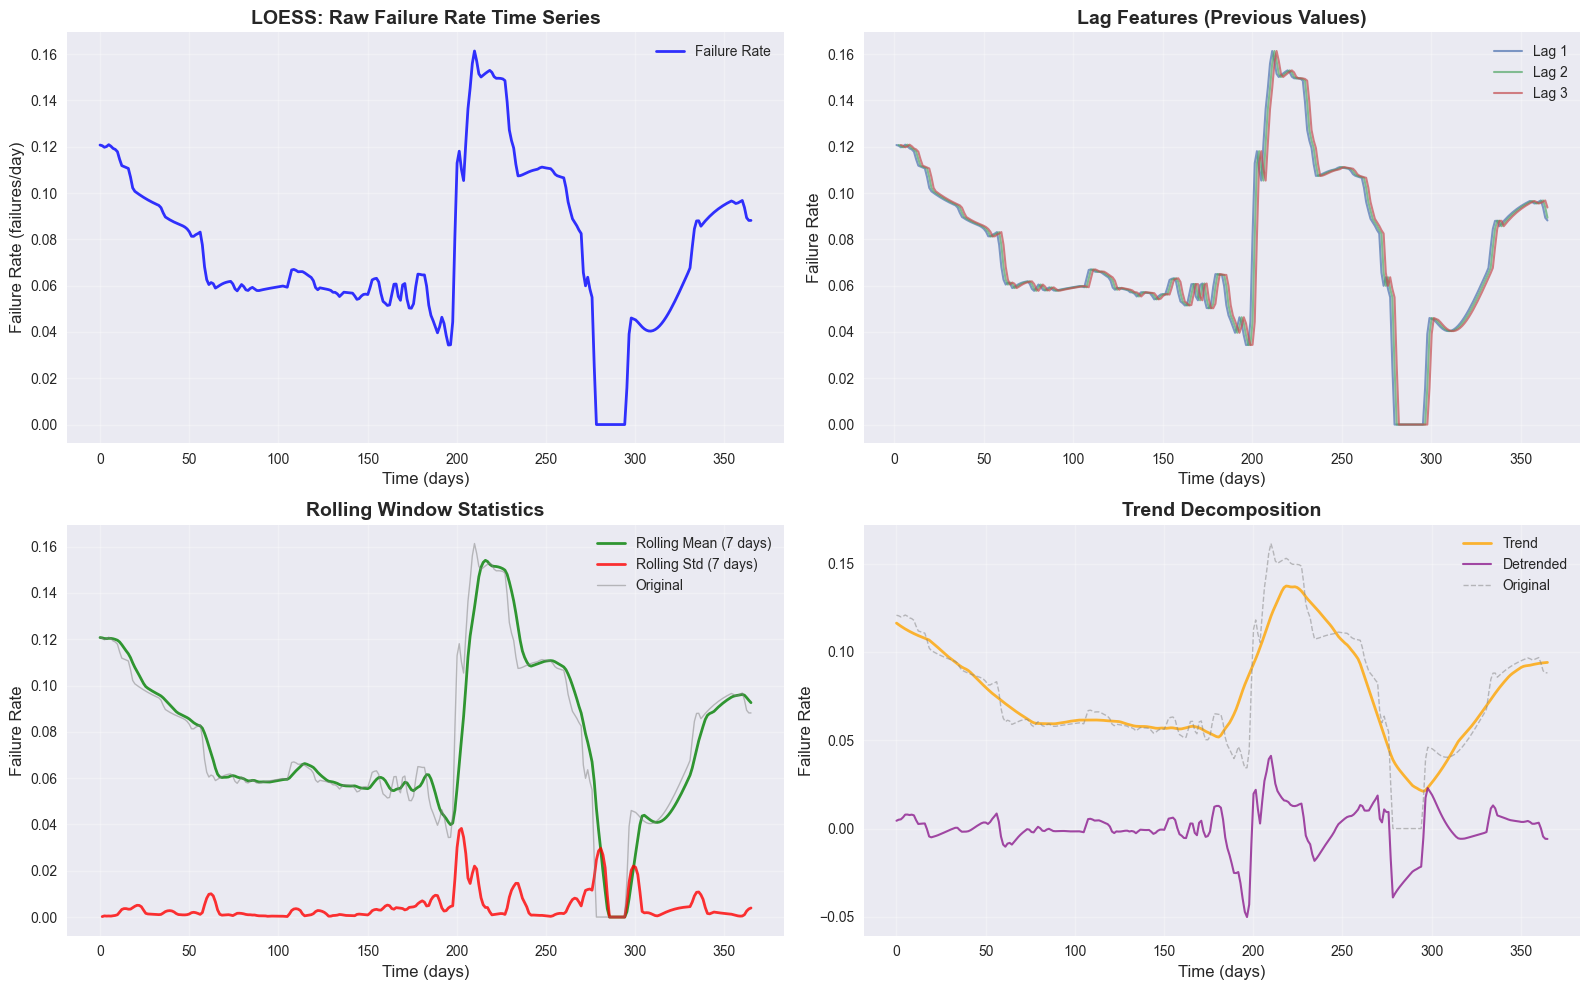


USAGE FOR TIME SERIES ML:

These features can be used directly in time series ML models:

1. **For LSTM/RNN/Transformer models:**
   - Use raw time series: ts_features['timeseries_data']['failure_rate']
   - Or use lag features: ts_features['failure_rate_lag_1'], lag_2, etc.
   - Add rolling statistics as additional features

2. **For ARIMA/Statistical models:**
   - Check autocorrelation: ts_features['autocorrelation']
   - Check stationarity: Use detrended_component
   - Use trend_component for trend analysis

3. **For Feature-based ML (XGBoost, Random Forest):**
   - Use all lag features
   - Use rolling statistics (mean, std, min, max)
   - Use volatility features
   - Use autocorrelation values
   - Use trend_strength, variance_change, etc.

4. **For Deep Learning:**
   - Use raw time series as input sequences
   - Add derived features as additional channels
   - Consider using trend and detrended components separately



In [ ]:
# Extract time series features from all methods
timeseries_features_all = {}

for name, result in results.items():
    try:
        ts_features = result['model'].extract_timeseries_features()
        timeseries_features_all[name] = ts_features
        print(f"✓ {name}: Extracted time series features")
        print(f"  - Raw time series length: {len(ts_features['timeseries_data']['failure_rate'])}")
        print(f"  - Lag features: {sum(1 for k in ts_features.keys() if 'lag' in k)}")
        print(f"  - Rolling features: {sum(1 for k in ts_features.keys() if 'rolling' in k)}")
        print(f"  - Autocorrelation lags: {len(ts_features.get('autocorrelation', {}))}")
        print()
    except Exception as e:
        print(f"✗ {name}: Failed to extract time series features - {e}")

# Example: Get time series data from best method
best_method_name = ml_df.index[0]
best_ts_features = timeseries_features_all[best_method_name]

print("="*80)
print(f"TIME SERIES DATA FROM BEST METHOD: {best_method_name}")
print("="*80)
print(f"\nRaw Time Series Data:")
print(f"  Time points shape: {best_ts_features['timeseries_data']['time_points'].shape}")
print(f"  Failure rate shape: {best_ts_features['timeseries_data']['failure_rate'].shape}")
print(f"  Cumulative failures shape: {best_ts_features['timeseries_data']['cumulative_failures'].shape}")

print(f"\nAvailable Features:")
print(f"  - Lag features: {[k for k in best_ts_features.keys() if 'lag' in k]}")
print(f"  - Rolling statistics: {[k for k in best_ts_features.keys() if 'rolling' in k][:5]}...")
print(f"  - Autocorrelation: {list(best_ts_features.get('autocorrelation', {}).keys())}")
print(f"  - Volatility features: {[k for k in best_ts_features.keys() if 'volatility' in k or 'change' in k]}")
print(f"  - Trend features: {[k for k in best_ts_features.keys() if 'trend' in k or 'detrended' in k]}")

# Visualize time series features
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Plot 1: Raw time series
ax = axes[0, 0]
ts_data = best_ts_features['timeseries_data']
ax.plot(ts_data['time_points'], ts_data['failure_rate'], 
       linewidth=2, label='Failure Rate', color='blue', alpha=0.8)
ax.set_xlabel('Time (days)', fontsize=12)
ax.set_ylabel('Failure Rate (failures/day)', fontsize=12)
ax.set_title(f'{best_method_name}: Raw Failure Rate Time Series', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Lag features (first 3 lags)
ax = axes[0, 1]
for lag in [1, 2, 3]:
    lag_key = f'failure_rate_lag_{lag}'
    if lag_key in best_ts_features:
        lag_data = best_ts_features[lag_key]
        valid_mask = ~np.isnan(lag_data)
        if np.any(valid_mask):
            ax.plot(ts_data['time_points'][valid_mask], lag_data[valid_mask],
                   linewidth=1.5, label=f'Lag {lag}', alpha=0.7)
ax.set_xlabel('Time (days)', fontsize=12)
ax.set_ylabel('Failure Rate', fontsize=12)
ax.set_title('Lag Features (Previous Values)', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 3: Rolling statistics
ax = axes[1, 0]
if 'rolling_mean_7' in best_ts_features:
    ax.plot(ts_data['time_points'], best_ts_features['rolling_mean_7'],
           linewidth=2, label='Rolling Mean (7 days)', color='green', alpha=0.8)
if 'rolling_std_7' in best_ts_features:
    ax.plot(ts_data['time_points'], best_ts_features['rolling_std_7'],
           linewidth=2, label='Rolling Std (7 days)', color='red', alpha=0.8)
ax.plot(ts_data['time_points'], ts_data['failure_rate'],
       linewidth=1, label='Original', color='gray', alpha=0.5)
ax.set_xlabel('Time (days)', fontsize=12)
ax.set_ylabel('Failure Rate', fontsize=12)
ax.set_title('Rolling Window Statistics', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 4: Trend decomposition
ax = axes[1, 1]
if 'trend_component' in best_ts_features:
    ax.plot(ts_data['time_points'], best_ts_features['trend_component'],
           linewidth=2, label='Trend', color='orange', alpha=0.8)
if 'detrended_component' in best_ts_features:
    ax.plot(ts_data['time_points'], best_ts_features['detrended_component'],
           linewidth=1.5, label='Detrended', color='purple', alpha=0.7)
ax.plot(ts_data['time_points'], ts_data['failure_rate'],
       linewidth=1, label='Original', color='gray', alpha=0.5, linestyle='--')
ax.set_xlabel('Time (days)', fontsize=12)
ax.set_ylabel('Failure Rate', fontsize=12)
ax.set_title('Trend Decomposition', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("USAGE FOR TIME SERIES ML:")
print("="*80)
print("""
These features can be used directly in time series ML models:

1. **For LSTM/RNN/Transformer models:**
   - Use raw time series: ts_features['timeseries_data']['failure_rate']
   - Or use lag features: ts_features['failure_rate_lag_1'], lag_2, etc.
   - Add rolling statistics as additional features

2. **For ARIMA/Statistical models:**
   - Check autocorrelation: ts_features['autocorrelation']
   - Check stationarity: Use detrended_component
   - Use trend_component for trend analysis

3. **For Feature-based ML (XGBoost, Random Forest):**
   - Use all lag features
   - Use rolling statistics (mean, std, min, max)
   - Use volatility features
   - Use autocorrelation values
   - Use trend_strength, variance_change, etc.

4. **For Deep Learning:**
   - Use raw time series as input sequences
   - Add derived features as additional channels
   - Consider using trend and detrended components separately
""")


## Key Takeaways

### Advantages of Non-Parametric Methods

1. **No Model Assumptions**: Don't need to assume power-law, exponential, or other distributions
2. **Automatic Adaptation**: Methods adapt to data patterns automatically
3. **Direct Failure Rate**: Derivative of cumulative = failure rate (no parameter interpretation needed)
4. **ML-Ready Features**: Extract features directly without model-specific parameters
5. **No Change Point Detection**: No need to find optimal piecewise segments
6. **Robust**: Work well even with noisy or irregular data

### Feature Extraction

All methods extract similar features:
- **Average failure rate**: Overall intensity
- **Failure rate slope**: Trend (positive = degrading, negative = improving)
- **Rate change ratio**: Early vs late period comparison
- **Peak failure rate**: Maximum intensity
- **Percentiles**: Distribution of failure rates
- **Variability measures**: CV, std, range

### When to Use Each Method

- **Savitzky-Golay**: Best for preserving local features while smoothing (recommended)
- **Moving Average**: Simplest, good for very noisy data
- **Gaussian Smoothing**: Good for smooth trends, less sensitive to outliers
- **LOESS**: Best for non-linear local patterns

### For ML Applications

These features can be used directly as:
- Input features for predictive models
- Comparison metrics (before/after PM)
- Trend indicators
- Equipment health scores

**No need for β, λ, or other parametric model parameters!**
